In [1]:
# =========================================================
# SECTION 1: IMPORTS AND CONFIGURATION
# =========================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import json
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch import nn

# Create export directory with timestamp
EXPORT_DIR = f"model_exports_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(EXPORT_DIR, exist_ok=True)
os.makedirs(f"{EXPORT_DIR}/models", exist_ok=True)
os.makedirs(f"{EXPORT_DIR}/scalers", exist_ok=True)
os.makedirs(f"{EXPORT_DIR}/datasets", exist_ok=True)
os.makedirs(f"{EXPORT_DIR}/results", exist_ok=True)

print(f"✅ Export directory created: {EXPORT_DIR}")
print(f"📁 Models: {EXPORT_DIR}/models")
print(f"📁 Scalers: {EXPORT_DIR}/scalers")
print(f"📁 Datasets: {EXPORT_DIR}/datasets")

# Set random seed for reproducibility
def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

print("✅ Setup complete!")

Mounted at /content/drive
✅ Export directory created: model_exports_20260613_230217
📁 Models: model_exports_20260613_230217/models
📁 Scalers: model_exports_20260613_230217/scalers
📁 Datasets: model_exports_20260613_230217/datasets
✅ Setup complete!


In [2]:
# =========================================================
# SECTION 2: DATA LOADING FUNCTIONS
# =========================================================

def latlon_to_xy(lat, lon, lat0=None, lon0=None):
    """Convert lat/lon to local XY coordinates in meters."""
    R = 6378137.0  # Earth radius (m)
    lat = np.asarray(lat)
    lon = np.asarray(lon)

    if lat0 is None:
        lat0 = lat[0]
    if lon0 is None:
        lon0 = lon[0]

    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    lat0_rad = np.radians(lat0)
    lon0_rad = np.radians(lon0)

    x = R * (lon_rad - lon0_rad) * np.cos(lat0_rad)
    y = R * (lat_rad - lat0_rad)

    return x, y

def assign_window_label(w_start, w_end, labels_df, overlap_thresh=0.3):
    w_len = w_end - w_start
    if w_len <= 0:
        return 'NORMAL'

    best_label = 'NORMAL'
    best_ratio = 0.0

    for _, row in labels_df.iterrows():
        overlap = max(0, min(w_end, row['end_ms']) - max(w_start, row['start_ms']))
        ratio = overlap / w_len
        if ratio > best_ratio:
            best_ratio = ratio
            if ratio >= overlap_thresh:
                best_label = row['label']

    return best_label

def load_all_sessions(dataset_path, interpolate_missing=True, target_hz=33.0, agg="mean", print_dist=False):
    """Load all sessions from dataset"""

    if not os.path.isdir(dataset_path):
        raise FileNotFoundError(f"Path not found: {dataset_path}")

    target_dt_ms = int(round(1000.0 / target_hz))
    sessions = []

    for folder in sorted(os.listdir(dataset_path)):
        folder_path = os.path.join(dataset_path, folder)
        if not os.path.isdir(folder_path):
            continue

        imu_path = os.path.join(folder_path, 'imu_filtered.csv')
        labels_path = os.path.join(folder_path, 'labels.csv')

        if not (os.path.exists(imu_path) and os.path.exists(labels_path)):
            print(f"  ⚠ Skipping '{folder}': missing IMU or labels")
            continue

        name_upper = folder.upper()
        car_type = 'BAIC' if 'BAIC' in name_upper else 'FIAT' if 'FIAT' in name_upper else 'unknown'
        session_type = 'NORMAL' if 'NORMAL' in name_upper else 'BRUSCO' if 'BRUSCO' in name_upper else 'unknown'

        # Load labels
        labels_df = pd.read_csv(labels_path)
        for col in ('start_ms', 'end_ms', 'duration_ms'):
            labels_df[col] = pd.to_numeric(labels_df[col], errors='coerce')
        labels_df.dropna(subset=['start_ms', 'end_ms'], inplace=True)
        labels_df['label'] = labels_df['label'].str.strip().str.upper()

        # Load IMU
        imu_df = pd.read_csv(imu_path)
        imu_df['t'] = pd.to_numeric(imu_df['t'], errors='coerce')
        imu_df.dropna(subset=['t'], inplace=True)
        imu_df.sort_values('t', inplace=True)
        imu_df['t'] = pd.to_timedelta(imu_df['t'], unit='ms')
        imu_df.set_index('t', inplace=True)

        # Interpolate missing data
        if interpolate_missing:
            imu_df = imu_df.resample('10ms').mean()
            imu_df = imu_df.interpolate().ffill().bfill()

        # Handle GPS
        if 'gps_lat' in imu_df.columns and 'gps_lon' in imu_df.columns:
            imu_df['gps_lat'] = imu_df['gps_lat'].replace([np.inf, -np.inf], np.nan)
            imu_df['gps_lon'] = imu_df['gps_lon'].replace([np.inf, -np.inf], np.nan)
            valid_gps = (imu_df['gps_lat'].notna() & imu_df['gps_lon'].notna())

            if valid_gps.sum() > 10:
                imu_df['gps_lat'] = imu_df['gps_lat'].interpolate(method='linear', limit_direction='both').ffill().bfill()
                imu_df['gps_lon'] = imu_df['gps_lon'].interpolate(method='linear', limit_direction='both').ffill().bfill()
                gps_x, gps_y = latlon_to_xy(imu_df['gps_lat'].values, imu_df['gps_lon'].values)
                imu_df['gps_x'] = gps_x
                imu_df['gps_y'] = gps_y
            else:
                imu_df['gps_x'] = 0.0
                imu_df['gps_y'] = 0.0
                imu_df['gps_lat'] = 0.0
                imu_df['gps_lon'] = 0.0

        # Resample to target frequency
        resampler = imu_df.resample(f"{target_dt_ms}ms")
        if agg == "mean":
            imu_df = resampler.mean()
        elif agg == "median":
            imu_df = resampler.median()
        elif agg == "last":
            imu_df = resampler.last()
        else:
            raise ValueError("agg must be 'mean' or 'last'")

        imu_df = imu_df.interpolate().ffill().bfill()
        imu_df.reset_index(inplace=True)
        imu_df['t'] = imu_df['t'].dt.total_seconds() * 1000.0

        print(f"  ✓ {folder} | {session_type} | {car_type} | IMU={len(imu_df)} rows | labels={len(labels_df)}")

        sessions.append({
            'folder_name': folder,
            'session_type': session_type,
            'car_type': car_type,
            'imu_df': imu_df,
            'labels_df': labels_df,
        })

    print(f"\nTotal sessions loaded: {len(sessions)}")
    return sessions

print("✅ Data loading functions ready!")

✅ Data loading functions ready!


In [3]:
# =========================================================
# SECTION 3: WINDOWING FUNCTIONS
# =========================================================

import numpy as np

SKIP_START_MS = 15000
WINDOW_SIZE_MS = 3000
OVERLAP_THRESH = 0.5
OVERLAP = 0.5

def build_windows_for_session(session, window_ms=WINDOW_SIZE_MS, overlap=OVERLAP,
                               overlap_thresh=OVERLAP_THRESH, skip_start_ms=SKIP_START_MS,
                               imu_channels=None, augment=False):
    imu_df = session['imu_df']
    labels_df = session['labels_df']

    if imu_channels is None:
        imu_channels = ['gx', 'gy', 'gz', 'ax', 'ay', 'az']

    if 't' not in imu_df.columns or any(c not in imu_df.columns for c in imu_channels):
        raise ValueError(f"Invalid session: {session['folder_name']}")

    imu_df = imu_df.sort_values('t')
    t = imu_df['t'].to_numpy(dtype=np.float64)
    data = imu_df[imu_channels].to_numpy(dtype=np.float32)

    if not (0.0 <= overlap < 1.0):
        raise ValueError("overlap debe estar en [0, 1)")

    step_ms = window_ms

    def _extract(offset=0.0):
        t_start = t.min() + skip_start_ms + offset
        t_end = t.max()
        if t_start >= t_end:
            return np.array([], dtype=int), np.array([]), np.array([])

        w0 = np.arange(t_start, t_end - window_ms, step_ms)
        w1 = w0 + window_ms

        s = np.searchsorted(t, w0, side='left')
        e = np.searchsorted(t, w1, side='left')
        valid = (e - s) >= 2
        return s[valid], w0[valid], w1[valid]

    starts, w0_arr, w1_arr = _extract()

    if augment:
        offset_ms = window_ms * (1.0 - overlap)
        a_starts, a_w0, a_w1 = _extract(offset=offset_ms)
        starts = np.concatenate([starts, a_starts])
        w0_arr = np.concatenate([w0_arr, a_w0])
        w1_arr = np.concatenate([w1_arr, a_w1])

    if len(starts) == 0:
        return np.empty((0, 0, 0), dtype=np.float32), np.empty((0,))

    expected_len = int(round(window_ms / 1000.0 * estimate_fs(t)))
    ends = starts + expected_len
    valid = ends <= len(data)

    starts = starts[valid]
    w0_arr = w0_arr[valid]
    w1_arr = w1_arr[valid]

    X = np.stack([data[s:s + expected_len] for s in starts])
    y = np.array([assign_window_label(w0, w1, labels_df, overlap_thresh)
                  for w0, w1 in zip(w0_arr, w1_arr)])

    return X, y


def estimate_fs(t):
    """Frecuencia de muestreo estimada (Hz) a partir de timestamps en ms."""
    dt = np.median(np.diff(t))
    return 1000.0 / dt

def build_cache(sessions, augment=True, imu_channels=None, verbose=True):
    """
    Pre-build windows for all sessions

    Parameters:
    -----------
    sessions : list
        List of session dictionaries
    augment : bool
        Whether to build augmented windows
    imu_channels : list
        IMU channels to use (default: ['gx', 'gy', 'gz', 'ax', 'ay', 'az'])
    verbose : bool
        Whether to print progress information

    Returns:
    --------
    cache : list
        List of dictionaries with session data and windows
    """

    if imu_channels is None:
        imu_channels = ['gx', 'gy', 'gz', 'ax', 'ay', 'az']

    TARGET_HZ = 30.0
    WINDOW_LEN = int(WINDOW_SIZE_MS * TARGET_HZ / 1000)

    def fix_len(X, tgt=WINDOW_LEN):
        """Ensure all windows have the same length"""
        if X is None or X.shape[0] == 0:
            return np.array([]).reshape(0, tgt, len(imu_channels))

        if len(X.shape) != 3:
            if verbose:
                print(f"      ⚠️  Forma inesperada: {X.shape}, intentando corregir...")
            # Intentar reshape si es posible
            try:
                X = X.reshape(-1, X.shape[-2], X.shape[-1])
            except:
                return np.array([]).reshape(0, tgt, len(imu_channels))

        T = X.shape[1]

        if T == tgt:
            return X.astype(np.float32)
        elif T > tgt:
            # Tomar los primeros tgt time steps
            return X[:, :tgt, :].astype(np.float32)
        else:
            # Rellenar con ceros al final
            pad = np.zeros((X.shape[0], tgt - T, X.shape[2]), dtype=np.float32)
            return np.concatenate([X, pad], axis=1).astype(np.float32)

    if verbose:
        print(f"\n  {'='*80}")
        print(f"  📦 CONSTRUYENDO CACHE DE VENTANAS")
        print(f"  {'='*80}")
        print(f"  Tamaño de ventana: {WINDOW_SIZE_MS}ms = {WINDOW_LEN} muestras @ {TARGET_HZ}Hz")
        print(f"  Canales IMU: {imu_channels}")
        print(f"  Augmentación: {'✅ Sí' if augment else '❌ No'}")
        print(f"  Sesiones a procesar: {len(sessions)}")
        print(f"\n  {'Session':<35} │ {'Clean':>8} │ {'Aug':>8} │ {'Clases'} ")
        print(f"  {'─'*35}─┼─{'─'*8}─┼─{'─'*8}─┼─{'─'*20}")

    cache = []
    skipped_sessions = []

    for i, s in enumerate(sessions):
        session_name = s.get('folder_name', f'Session_{i}')

        try:
            # ── Construir ventanas limpias ──
            Xc, yc = build_windows_for_session(s, augment=False, imu_channels=imu_channels)

            # Validar ventanas limpias
            if Xc is None or len(Xc) == 0:
                if verbose:
                    print(f"  {session_name:<35} │ {'0':>8} │ {'---':>8} │ ❌ Sin ventanas limpias")
                skipped_sessions.append((session_name, "Sin ventanas limpias"))
                continue

            # Arreglar longitud
            Xc = fix_len(Xc)

            if Xc.shape[0] == 0:
                if verbose:
                    print(f"  {session_name:<35} │ {'0':>8} │ {'---':>8} │ ❌ Error al procesar ventanas")
                skipped_sessions.append((session_name, "Error procesando ventanas"))
                continue

            # ── Construir ventanas augmentadas (si se solicita) ──
            if augment:
                try:
                    Xa, ya = build_windows_for_session(s, augment=True, imu_channels=imu_channels)

                    if Xa is None or len(Xa) == 0:
                        if verbose:
                            print(f"  {session_name:<35} │ {Xc.shape[0]:>8} │ {'0':>8} │ ⚠️  Sin augmentación")
                        Xa = Xc.copy()
                        ya = yc.copy()
                    else:
                        Xa = fix_len(Xa)
                        if Xa.shape[0] == 0:
                            Xa = Xc.copy()
                            ya = yc.copy()
                except Exception as e:
                    if verbose:
                        print(f"  {session_name:<35} │ {Xc.shape[0]:>8} │ {'0':>8} │ ⚠️  Error augmentación: {str(e)[:30]}")
                    Xa = Xc.copy()
                    ya = yc.copy()
            else:
                Xa = Xc.copy()
                ya = yc.copy()

            # ── Obtener clases presentes ──
            classes_present = sorted(set(yc)) if len(yc) > 0 else []
            classes_str = ', '.join(classes_present[:3])  # Primeras 3 clases
            if len(classes_present) > 3:
                classes_str += f' +{len(classes_present)-3}'

            if verbose:
                print(f"  {session_name:<35} │ {Xc.shape[0]:>8} │ {Xa.shape[0]:>8} │ {classes_str}")

            # ── Guardar en cache ──
            cache.append({
                'session': s,
                'session_name': session_name,
                'Xc': Xc,
                'yc': yc,
                'Xa': Xa,
                'ya': ya,
                'n_clean': Xc.shape[0],
                'n_augmented': Xa.shape[0] if augment else Xc.shape[0],
                'classes': classes_present,
                'n_classes': len(classes_present)
            })

        except Exception as e:
            if verbose:
                print(f"  {session_name:<35} │ {'---':>8} │ {'---':>8} │ ❌ Error: {str(e)[:40]}")
            skipped_sessions.append((session_name, f"Error: {str(e)[:50]}"))
            continue

    # ── RESUMEN ──
    if verbose:
        print(f"\n  {'='*80}")
        print(f"  RESUMEN DEL CACHE")
        print(f"  {'='*80}")

        if len(cache) > 0:
            total_clean = sum(c['n_clean'] for c in cache)
            total_aug = sum(c['n_augmented'] for c in cache)

            # Distribución de clases (ventanas limpias)
            all_labels_clean = np.concatenate([c['yc'] for c in cache])
            unique_classes, class_counts = np.unique(all_labels_clean, return_counts=True)

            print(f"  ✅ Sesiones procesadas: {len(cache)}/{len(sessions)}")
            print(f"  📊 Total ventanas limpias: {total_clean}")
            if augment:
                print(f"  📊 Total ventanas augmentadas: {total_aug}")

            print(f"\n  Distribución de clases (ventanas limpias):")
            for cls, count in zip(unique_classes, class_counts):
                pct = 100 * count / total_clean
                bar = '█' * int(pct / 2)
                print(f"    {cls:<20}: {count:>6} ({pct:5.1f}%) {bar}")

            # Verificar balance
            min_count = class_counts.min()
            max_count = class_counts.max()
            imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

            print(f"\n  Balance de clases:")
            print(f"    Clase mayoritaria: {unique_classes[class_counts.argmax()]} ({max_count})")
            print(f"    Clase minoritaria: {unique_classes[class_counts.argmin()]} ({min_count})")
            print(f"    Ratio desbalance: {imbalance_ratio:.2f}:1")

            if imbalance_ratio > 10:
                print(f"    ⚠️  Dataset muy desbalanceado (ratio > 10:1)")
            elif imbalance_ratio > 5:
                print(f"    ⚠️  Dataset moderadamente desbalanceado (ratio > 5:1)")
            else:
                print(f"    ✅ Dataset razonablemente balanceado")

        if skipped_sessions:
            print(f"\n  ❌ Sesiones omitidas ({len(skipped_sessions)}):")
            for name, reason in skipped_sessions:
                print(f"    - {name}: {reason}")

        print(f"  {'='*80}\n")

    # ── ADVERTENCIAS ──
    if len(cache) == 0:
        raise ValueError("❌ ERROR: No se pudo procesar ninguna sesión. Verifica los datos de entrada.")

    if len(cache) < 3:
        print(f"  ⚠️  ADVERTENCIA: Solo {len(cache)} sesiones en el cache. LOSO necesita al menos 3 para ser significativo.")

    # Verificar que todas las sesiones tengan al menos 2 clases
    few_class_sessions = [c['session_name'] for c in cache if c['n_classes'] < 2]
    if few_class_sessions:
        print(f"  ⚠️  ADVERTENCIA: Las siguientes sesiones tienen menos de 2 clases:")
        for name in few_class_sessions:
            print(f"    - {name}")
        print(f"    Esto puede causar problemas en la validación cruzada LOSO.")

    return cache

print("✅ Windowing functions ready!")


✅ Windowing functions ready!


In [4]:
# =========================================================
# SECTION 4: MODEL DEFINITIONS
# =========================================================

class CNN1D(nn.Module):
    def __init__(self, C, n_classes, dropout=0.3):
        super().__init__()

        def block(in_ch, out_ch, k=3):
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=k, padding=k//2),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(),
                nn.MaxPool1d(2)
            )

        self.features = nn.Sequential(
            nn.Conv1d(C, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            block(32, 64),
            block(64, 128),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

class ANNModel(nn.Module):
    """Multi-layer perceptron for feature-based classification"""

    def __init__(self, in_dim, n_classes, hidden=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        layers.append(nn.Linear(d, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def make_sklearn(name):
    """Create sklearn models"""
    if name == 'SVM':
        return SVC(kernel='rbf', C=10, gamma='scale', probability=True,
                   random_state=42, class_weight='balanced')
    if name == 'RF':
        return RandomForestClassifier(n_estimators=30, max_depth=8, n_jobs=-1,
                                      random_state=42, class_weight='balanced')
    if name == 'XGB':
        return XGBClassifier(n_estimators=30, max_depth=8, learning_rate=0.05,
                             eval_metric='mlogloss', n_jobs=-1, random_state=42,
                             objective="multi:softprob", num_class=5, verbosity=0)
    raise ValueError(f"Unknown model: {name}")

def extract_features(X):
    """Extract features: mean, std, min, max, energy per channel"""
    N, T, C = X.shape
    features = np.zeros((N, C * 5))

    for i in range(N):
        for c in range(C):
            signal = X[i, :, c]
            features[i, c*5:(c+1)*5] = [
                np.mean(signal),
                np.std(signal),
                np.min(signal),
                np.max(signal),
                np.sum(signal**2),
            ]

    return features

print("✅ Model definitions ready!")

✅ Model definitions ready!


In [5]:
# =========================================================
# SECTION 5: LOSO TRAINING FUNCTIONS (WITH MACs & SIZE)
# =========================================================


def zscore(X_tr, X_te):
    """
    Z-score normalization per channel (feature dimension)

    Parameters:
    -----------
    X_tr : numpy array of shape (n_samples_tr, time_steps, n_channels)
        Training data to fit scaler
    X_te : numpy array of shape (n_samples_te, time_steps, n_channels)
        Test data to transform using training scaler

    Returns:
    --------
    Xtr_norm : numpy array
        Normalized training data
    Xte_norm : numpy array
        Normalized test data
    scaler : StandardScaler
        Fitted scaler object
    """
    N_tr, T, C = X_tr.shape
    N_te = X_te.shape[0]

    # Reshape to (n_samples * time_steps, n_channels)
    X_tr_reshaped = X_tr.reshape(-1, C)
    X_te_reshaped = X_te.reshape(-1, C)

    # Fit scaler on training data
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_reshaped)
    X_te_scaled = scaler.transform(X_te_reshaped)

    # Reshape back to original dimensions
    Xtr_norm = X_tr_scaled.reshape(N_tr, T, C).astype(np.float32)
    Xte_norm = X_te_scaled.reshape(N_te, T, C).astype(np.float32)

    return Xtr_norm, Xte_norm, scaler

def fit_torch(model, Xtr, ytr, Xval, yval, epochs=60, bs=64, lr=1e-3, device='cpu',
              patience=10, class_weights=None):
    """
    Train PyTorch model with early stopping, learning rate scheduling, and class weights

    Parameters:
    -----------
    model : nn.Module
        PyTorch model to train
    Xtr : numpy array
        Training features (n_samples, n_features)
    ytr : numpy array
        Training labels (n_samples,)
    Xval : numpy array
        Validation features
    yval : numpy array
        Validation labels
    epochs : int
        Maximum number of epochs
    bs : int
        Batch size
    lr : float
        Learning rate
    device : str
        'cuda' or 'cpu'
    patience : int
        Early stopping patience
    class_weights : array
        Class weights for loss function (optional)

    Returns:
    --------
    model : nn.Module
        Trained model with best weights
    """

    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)

    # Convert to tensors
    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    Xval_t = torch.tensor(Xval, dtype=torch.float32).to(device)
    yval_t = torch.tensor(yval, dtype=torch.long).to(device)

    # Class weights for loss function
    if class_weights is None:
        counts = np.bincount(ytr)
        cw = 1.0 / (counts + 1e-6)
        cw = cw / cw.sum()  # Normalize
    else:
        cw = class_weights

    cw_t = torch.tensor(cw, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=cw_t)

    # Weighted sampler for balanced batches
    sample_weights = cw[ytr]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    dataloader = DataLoader(
        TensorDataset(Xtr_t, ytr_t),
        batch_size=bs,
        sampler=sampler,
        drop_last=False
    )

    best_loss, best_state, wait = float('inf'), None, 0

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0

        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)

            opt.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            opt.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(dataloader)

        # Validation
        model.eval()
        with torch.no_grad():
            logits = model(Xval_t)
            val_loss = criterion(logits, yval_t).item()

        # Update learning rate
        sched.step(val_loss)

        # Early stopping
        if val_loss < best_loss - 1e-4:
            best_loss = val_loss
            best_state = {k: p.cpu().clone() for k, p in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"    Early stopping at epoch {epoch+1}")
                break

        # Print progress every 20 epochs
        if (epoch + 1) % 20 == 0:
            print(f"    Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Load best model
    if best_state is not None:
        model.load_state_dict(best_state)

    return model

def estimate_macs(model, model_name, input_shape=None, X_sample=None):
    """
    Estimate MACs (Multiply-Accumulate operations) for inference
    """
    try:
        if model_name in ('RF', 'XGB'):
            # For tree-based models: approximate based on trees and depth
            if model_name == 'RF':
                n_estimators = model.n_estimators
                max_depth = model.max_depth or 10
                n_features = model.n_features_in_
                # Rough estimate: each tree does ~ (2^depth * features) operations
                macs = n_estimators * (2 ** min(max_depth, 15)) * n_features
            else:  # XGB
                n_estimators = model.n_estimators
                max_depth = model.max_depth or 6
                n_features = model.n_features_in_
                macs = n_estimators * (2 ** min(max_depth, 15)) * n_features
            return max(300, macs)  # Minimum 300 MACs

        elif model_name == 'SVM':
            # SVM: number of support vectors * features
            if hasattr(model, 'support_vectors_'):
                n_sv = len(model.support_vectors_)
                n_features = model.support_vectors_.shape[1]
                return n_sv * n_features
            return 10000  # Default estimate

        elif model_name == 'ANN_RAW' or model_name == 'ANN_FEAT':
            # Calculate MACs for neural network
            macs = 0
            for name, module in model.named_modules():
                if isinstance(module, nn.Linear):
                    macs += module.in_features * module.out_features
            return macs

        elif model_name == 'CNN1D':
            # Simplified CNN MAC calculation
            macs = 0
            for name, module in model.named_modules():
                if isinstance(module, nn.Conv1d):
                    # MACs = output_length * in_channels * kernel_size * out_channels
                    macs += module.out_channels * module.kernel_size[0] * module.in_channels * 100  # Approx
            return max(macs, 1000)

        else:
            return None
    except:
        return None

def get_model_size_mb(model, model_name):
    """
    Calculate actual model size in MB
    """
    try:
        import tempfile
        if model_name in ('RF', 'XGB', 'SVM'):
            # For sklearn models
            with tempfile.NamedTemporaryFile(delete=True, suffix='.pkl') as f:
                joblib.dump(model, f)
                f.flush()
                size_bytes = os.path.getsize(f.name)
                return size_bytes / (1024 ** 2)
        else:
            # For PyTorch models
            total_bytes = 0
            for p in model.parameters():
                total_bytes += p.numel() * p.element_size()
            for b in model.buffers():
                total_bytes += b.numel() * b.element_size()
            return total_bytes / (1024 ** 2)
    except:
        return None

def run_loso_with_metrics(cache, model_name, use_augment=True, torch_epochs=60,
                          torch_bs=64, torch_lr=1e-3, export_dir=None, config_name="default"):
    """
    LOSO with MACs and Size calculations
    """

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Encode labels
    all_y = np.concatenate([c['yc'] for c in cache if len(c['yc'])])
    le = LabelEncoder().fit(all_y)
    K = len(le.classes_)
    T, C = cache[0]['Xc'].shape[1], cache[0]['Xc'].shape[2]

    print(f"\n{'═'*68}")
    print(f"  LOSO  │  {model_name}  │  aug={use_augment}  │  folds={len(cache)}  │  classes={list(le.classes_)}")
    print(f"{'═'*68}")

    if export_dir:
        fold_dir = f"{export_dir}/folds/{config_name}/{model_name}"
        os.makedirs(fold_dir, exist_ok=True)

    fold_results = []

    for i, entry in enumerate(cache):
        Xte, yte = entry['Xc'], entry['yc']
        if Xte.shape[0] == 0:
            continue

        session_name = entry['session']['folder_name']
        print(f"\n  Fold {i+1}/{len(cache)}: Test = {session_name}")

        # Build training set
        X_key, y_key = ('Xa', 'ya') if use_augment else ('Xc', 'yc')
        Xtr = np.concatenate([c[X_key] for j, c in enumerate(cache) if j != i and c[X_key].shape[0] > 0])
        ytr = np.concatenate([c[y_key] for j, c in enumerate(cache) if j != i and c[y_key].shape[0] > 0])

        # Fix window lengths
        if Xtr.shape[1] != T:
            if Xtr.shape[1] > T:
                Xtr = Xtr[:, :T, :]
            else:
                pad = np.zeros((Xtr.shape[0], T - Xtr.shape[1], Xtr.shape[2]), dtype=np.float32)
                Xtr = np.concatenate([Xtr, pad], axis=1)

        if Xte.shape[1] != T:
            if Xte.shape[1] > T:
                Xte = Xte[:, :T, :]
            else:
                pad = np.zeros((Xte.shape[0], T - Xte.shape[1], Xte.shape[2]), dtype=np.float32)
                Xte = np.concatenate([Xte, pad], axis=1)

        # Normalize
        Xtr_n, Xte_n, scaler = zscore(Xtr, Xte)
        ytr_enc = le.transform(ytr)
        yte_enc = le.transform(yte)
        N = Xtr_n.shape[0]

        # Class weights
        from sklearn.utils.class_weight import compute_class_weight
        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=np.unique(ytr_enc),
            y=ytr_enc
        )

        # Validation split
        from sklearn.model_selection import StratifiedShuffleSplit
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
        tr_idx, val_idx = next(sss.split(Xtr_n, ytr_enc))

        # rng = np.random.default_rng(42)
        # idx = rng.permutation(N)
        # val_n = max(32, int(0.1 * N))
        # val_idx, tr_idx = idx[:val_n], idx[val_n:]

        model = None
        yp = None
        macs_value = None
        size_mb = None

        # ── Train model and calculate metrics ──
        if model_name in ('SVM'):
            model = make_sklearn(model_name)
            Xtr_f = extract_features(Xtr_n)
            Xte_f = extract_features(Xte_n)

            model.fit(Xtr_f, ytr_enc)
            yp = model.predict(Xte_f)

            # Calculate MACs and Size
            macs_value = estimate_macs(model, model_name, input_shape=Xtr_f.shape[1])
            size_mb = get_model_size_mb(model, model_name)

            if export_dir:
                joblib.dump(model, f"{fold_dir}/fold_{i+1}_{session_name}.pkl")
                joblib.dump(scaler, f"{fold_dir}/fold_{i+1}_scaler.pkl")
        if model_name in ('RF', 'XGB'):
            model = make_sklearn(model_name)
            Xtr_f = extract_features(Xtr_n)
            Xte_f = extract_features(Xte_n)

            model.fit(Xtr_f, ytr_enc)
            yp = model.predict(Xte_f)

            # Calculate MACs and Size
            macs_value = estimate_macs(model, model_name, input_shape=Xtr_f.shape[1])
            size_mb = get_model_size_mb(model, model_name)


        elif model_name == 'ANN_FEAT':
            Xtr_f = extract_features(Xtr_n)
            Xte_f = extract_features(Xte_n)

            model = ANNModel(in_dim=Xtr_f.shape[1], n_classes=K)
            model = fit_torch(
                model,
                Xtr_f[tr_idx], ytr_enc[tr_idx],
                Xtr_f[val_idx], ytr_enc[val_idx],
                epochs=torch_epochs, bs=torch_bs, lr=torch_lr, device=device,
                class_weights=class_weights
            )

            model.eval()
            with torch.no_grad():
                yp = model(torch.tensor(Xte_f).float().to(device)).argmax(1).cpu().numpy()

            # Calculate MACs and Size
            macs_value = estimate_macs(model, model_name)
            size_mb = get_model_size_mb(model, model_name)

            if export_dir:
                torch.save(model.state_dict(), f"{fold_dir}/fold_{i+1}_{session_name}.pth")
                joblib.dump(scaler, f"{fold_dir}/fold_{i+1}_scaler.pkl")

        elif model_name == 'ANN_RAW':
            Xf = Xtr_n.reshape(N, -1)
            Xte_f = Xte_n.reshape(len(Xte_n), -1)

            model = ANNModel(in_dim=Xf.shape[1], n_classes=K)
            model = fit_torch(
                model,
                Xf[tr_idx], ytr_enc[tr_idx],
                Xf[val_idx], ytr_enc[val_idx],
                epochs=torch_epochs, bs=torch_bs, lr=torch_lr, device=device,
                class_weights=class_weights
            )

            model.eval()
            with torch.no_grad():
                yp = model(torch.tensor(Xte_f).float().to(device)).argmax(1).cpu().numpy()

            macs_value = estimate_macs(model, model_name)
            size_mb = get_model_size_mb(model, model_name)

            if export_dir:
                torch.save(model.state_dict(), f"{fold_dir}/fold_{i+1}_{session_name}.pth")
                joblib.dump(scaler, f"{fold_dir}/fold_{i+1}_scaler.pkl")

        elif model_name == 'CNN1D':
            Xt = Xtr_n.transpose(0, 2, 1)
            Xv_t = Xt[val_idx]
            Xt_t = Xt[tr_idx]
            C_real = Xt.shape[1]
            T_real = Xt.shape[2]

            model = CNN1D(C=C_real, n_classes=K)
            model = fit_torch(
                model,
                Xt_t, ytr_enc[tr_idx],
                Xv_t, ytr_enc[val_idx],
                epochs=torch_epochs, bs=torch_bs, lr=torch_lr, device=device,
                class_weights=class_weights
            )

            model.eval()
            with torch.no_grad():
                Xte_t = torch.tensor(Xte_n.transpose(0, 2, 1)).to(device)
                yp = model(Xte_t).argmax(1).cpu().numpy()

            macs_value = estimate_macs(model, model_name, input_shape=(C_real, T_real))
            size_mb = get_model_size_mb(model, model_name)

            if export_dir:
                torch.save(model.state_dict(), f"{fold_dir}/fold_{i+1}_{session_name}.pth")
                joblib.dump(scaler, f"{fold_dir}/fold_{i+1}_scaler.pkl")

        # Calculate metrics
        acc = accuracy_score(yte_enc, yp)
        f1 = f1_score(yte_enc, yp, average='macro', zero_division=0)
        prec = precision_score(yte_enc, yp, average='macro', zero_division=0)
        rec = recall_score(yte_enc, yp, average='macro', zero_division=0)

        fold_results.append({
            'fold': i,
            'session': session_name,
            'acc': acc,
            'f1': f1,
            'prec': prec,
            'rec': rec,
            'macs': macs_value,
            'size_mb': size_mb,
            'n_train': N,
            'n_test': Xte.shape[0]
        })

        print(f"    Results: acc={acc:.3f}, f1={f1:.3f}, MACs={macs_value}, Size={size_mb:.3f}MB")

    # Summary statistics
    accs = [r['acc'] for r in fold_results]
    f1s = [r['f1'] for r in fold_results]
    precs = [r['prec'] for r in fold_results]
    recs = [r['rec'] for r in fold_results]
    macs_list = [r['macs'] for r in fold_results if r['macs'] is not None]
    size_list = [r['size_mb'] for r in fold_results if r['size_mb'] is not None]

    summary = dict(
        model=model_name,
        classes=list(le.classes_),
        n_folds=len(fold_results),
        acc_mean=np.mean(accs),
        acc_std=np.std(accs),
        f1_mean=np.mean(f1s),
        f1_std=np.std(f1s),
        prec_mean=np.mean(precs),
        prec_std=np.std(precs),
        rec_mean=np.mean(recs),
        rec_std=np.std(recs),
        macs_mean=np.mean(macs_list) if macs_list else None,
        macs_std=np.std(macs_list) if macs_list else None,
        size_mb_mean=np.mean(size_list) if size_list else None,
        size_mb_std=np.std(size_list) if size_list else None,
        fold_results=fold_results
    )

    print(f"{'─'*68}")
    print(f"  SUMMARY for {model_name}:")
    print(f"  Accuracy  : {summary['acc_mean']:.3f} ± {summary['acc_std']:.3f}")
    print(f"  F1 macro  : {summary['f1_mean']:.3f} ± {summary['f1_std']:.3f}")
    if summary['macs_mean']:
        print(f"  MACs      : {summary['macs_mean']:.0f} ± {summary['macs_std']:.0f}")
    if summary['size_mb_mean']:
        print(f"  Size (MB) : {summary['size_mb_mean']:.3f} ± {summary['size_mb_std']:.3f}")
    print(f"{'═'*68}")

    # Save summary
    if export_dir:
        with open(f"{fold_dir}/summary.json", 'w') as f:
            serializable = {
                'model': summary['model'],
                'classes': [str(c) for c in summary['classes']],
                'n_folds': summary['n_folds'],
                'acc_mean': float(summary['acc_mean']),
                'acc_std': float(summary['acc_std']),
                'f1_mean': float(summary['f1_mean']),
                'f1_std': float(summary['f1_std']),
                'prec_mean': float(summary['prec_mean']),
                'prec_std': float(summary['prec_std']),
                'rec_mean': float(summary['rec_mean']),
                'rec_std': float(summary['rec_std']),
                'macs_mean': float(summary['macs_mean']) if summary['macs_mean'] else None,
                'size_mb_mean': float(summary['size_mb_mean']) if summary['size_mb_mean'] else None,
                'fold_results': [
                    {
                        'fold': r['fold'],
                        'session': r['session'],
                        'acc': float(r['acc']),
                        'f1': float(r['f1']),
                        'macs': int(r['macs']) if r['macs'] else None,
                        'size_mb': float(r['size_mb']) if r['size_mb'] else None,
                        'n_train': int(r['n_train']),
                        'n_test': int(r['n_test'])
                    }
                    for r in summary['fold_results']
                ]
            }
            json.dump(serializable, f, indent=2)

    return summary

# Updated run_experiment
def run_experiment(sessions, models='all', use_augment=True, imu_channels=None,
                   torch_epochs=60, torch_bs=64, torch_lr=1e-3,
                   export_dir=None, config_name="default"):
    """Run experiment with LOSO including MACs and size metrics"""

    ALL_MODELS = ['SVM', 'RF', 'XGB', 'CNN1D', 'ANN_RAW', 'ANN_FEAT']
    #ALL_MODELS = ['RF', 'XGB']

    if models == 'all':
        models = ALL_MODELS
    if imu_channels is None:
        imu_channels = ['gx', 'gy', 'gz', 'ax', 'ay', 'az']

    print(f"\n{'═'*68}")
    print(f"  Building window cache (sessions={len(sessions)}, augment={use_augment})")
    print(f"  Channels: {imu_channels}")
    print(f"{'═'*68}")

    cache = build_cache(sessions, augment=use_augment, imu_channels=imu_channels)

    results = {}
    for m in models:
        results[m] = run_loso_with_metrics(
            cache, m, use_augment=use_augment,
            torch_epochs=torch_epochs, torch_bs=torch_bs, torch_lr=torch_lr,
            export_dir=export_dir, config_name=config_name
        )

    # Comparison table with MACs and Size
    print(f"\n{'═'*78}")
    print(f"  {'Model':<8} │ {'Acc':>7} ± {'std':>5} │ {'F1':>7} ± {'std':>5} │ {'MACs':>10} │ {'Size(MB)':>9}")
    print(f"  {'─'*8}─┼─{'─'*13}─┼─{'─'*13}─┼─{'─'*10}─┼─{'─'*9}")
    for m, r in results.items():
        macs_str = f"{r['macs_mean']/1000:.1f}K" if r['macs_mean'] and r['macs_mean'] > 1000 else f"{r['macs_mean']:.0f}" if r['macs_mean'] else "N/A"
        size_str = f"{r['size_mb_mean']:.3f}" if r['size_mb_mean'] else "N/A"
        print(f"  {m:<8} │ {r['acc_mean']:>7.3f} ± {r['acc_std']:>5.3f} │ "
              f"{r['f1_mean']:>7.3f} ± {r['f1_std']:>5.3f} │ {macs_str:>10} │ {size_str:>9}")
    print(f"{'═'*78}\n")

    return results

In [6]:
# =========================================================
# SECTION 6: EXPERIMENT 1 - CHANNEL TYPE COMPARISON
# =========================================================
# !pip uninstall sympy -y -q
# !pip install sympy

# Define experiment configurations
EXPERIMENT_1_CONFIGS = {
    "RAW_IMU": {
        "channels": ['gx', 'gy', 'gz', 'ax', 'ay', 'az'],
        "description": "Raw IMU data (gyro + accel)"
    },
    "EKF_IMU": {
        "channels": ['ekf_gx', 'ekf_gy', 'ekf_gz', 'ekf_ax', 'ekf_ay', 'ekf_az'],
        "description": "Kalman filtered IMU"
    },
    "LPF_IMU": {
        "channels": ['lpf_gx', 'lpf_gy', 'lpf_gz', 'lpf_ax', 'lpf_ay', 'lpf_az'],
        "description": "Low-pass filtered IMU"
    }
}

# MODELS_TO_COMPARE = ['RF', 'XGB', 'SVM', 'ANN_RAW', 'ANN_FEAT']
MODELS_TO_COMPARE = ['RF', 'XGB']

print("="*70)
print("EXPERIMENT 1: Comparing RAW, EKF, and LPF channels")
print("="*70)

# Load sessions
VEHICLE_DATASET_PATH = '/content/drive/MyDrive/LabeledDataset'

print("\nLoading sessions...")
sessions = load_all_sessions(VEHICLE_DATASET_PATH,
                             interpolate_missing=True,
                             target_hz=30.0,
                             agg='mean',
                             print_dist=False)

BAIC_sessions = [s for s in sessions if s['car_type'] == 'BAIC']

print(f"\n✅ Loaded {len(BAIC_sessions)} BAIC sessions")

# Run experiments
results_exp1 = {}

for config_name, config in EXPERIMENT_1_CONFIGS.items():
    print(f"\n{'='*70}")
    print(f"Running: {config_name} - {config['description']}")
    print(f"{'='*70}")

    results = run_experiment(
        BAIC_sessions,
        imu_channels=config['channels'],
        use_augment=True,
        export_dir=EXPORT_DIR,
        torch_lr=1e-4,
        torch_epochs=200
    )

    results_exp1[config_name] = results

    # Save results
    with open(f"{EXPORT_DIR}/results/exp1_{config_name}_results.json", 'w') as f:
        serializable_results = {}
        for model, res in results.items():
            serializable_results[model] = {
                'acc_mean': float(res['acc_mean']),
                'acc_std': float(res['acc_std']),
                'f1_mean': float(res['f1_mean']),
                'f1_std': float(res['f1_std']),
                'prec_mean': float(res.get('prec_mean', 0)),
                'prec_std': float(res.get('prec_std', 0)),
                'rec_mean': float(res.get('rec_mean', 0)),
                'rec_std': float(res.get('rec_std', 0)),
                'classes': [str(c) for c in res['classes']]
            }
        json.dump(serializable_results, f, indent=2)

    print(f"✅ Results saved to: {EXPORT_DIR}/results/exp1_{config_name}_results.json")

print("\n✅ EXPERIMENT 1 COMPLETE!")

EXPERIMENT 1: Comparing RAW, EKF, and LPF channels

Loading sessions...
  ✓ BAIC  MANEJO BRUSCO 1 | BRUSCO | BAIC | IMU=4333 rows | labels=22
  ✓ BAIC  MANEJO BRUSCO 2 | BRUSCO | BAIC | IMU=4182 rows | labels=15
  ✓ BAIC  MANEJO BRUSCO 3 | BRUSCO | BAIC | IMU=4151 rows | labels=16
  ✓ BAIC  MANEJO NORMAL 1 | NORMAL | BAIC | IMU=5636 rows | labels=15
  ✓ BAIC  MANEJO NORMAL 2 | NORMAL | BAIC | IMU=5667 rows | labels=14
  ✓ BAIC  MANEJO NORMAL 3 | NORMAL | BAIC | IMU=5757 rows | labels=14
  ✓ FIAT MANEJO BRUSCO 1 | BRUSCO | FIAT | IMU=4061 rows | labels=14
  ✓ FIAT MANEJO BRUSCO 2 | BRUSCO | FIAT | IMU=4303 rows | labels=13
  ✓ FIAT MANEJO BRUSCO 3 | BRUSCO | FIAT | IMU=4061 rows | labels=10
  ✓ FIAT MANEJO NORMAL 1 | NORMAL | FIAT | IMU=6394 rows | labels=15
  ✓ FIAT MANEJO NORMAL 2 | NORMAL | FIAT | IMU=5818 rows | labels=14
  ✓ FIAT MANEJO NORMAL 3 | NORMAL | FIAT | IMU=6061 rows | labels=14

Total sessions loaded: 12

✅ Loaded 6 BAIC sessions

Running: RAW_IMU - Raw IMU data (gyro + 

In [7]:
# =========================================================
# SECTION 7: EXPERIMENT 2 - FEATURE COMBINATIONS (CORREGIDO)
# =========================================================

EXPERIMENT_2_CONFIGS = {
    "IMU6": {
        "channels": ['lpf_gx', 'lpf_gy', 'lpf_gz', 'lpf_ax', 'lpf_ay', 'lpf_az'],
        "description": "Full LPF IMU (6 channels)"
    },
    "IMU3": {
        "channels": ['lpf_gz', 'lpf_ax', 'lpf_ay'],
        "description": "Selected IMU (gyro_z, accel_x, accel_y)"
    },
    "IMU3+GPS": {
        "channels": ['lpf_gz', 'lpf_ax', 'lpf_ay', 'gps_speed', 'gps_course'],
        "description": "Selected IMU + GPS (speed + course)"
    },
    "GPS": {
        "channels": ['gps_speed', 'gps_x', 'gps_y', 'gps_course'],
        "description": "Selected GPS (speed, x, y, course)"
    },
    "IMU6+GPS": {
        "channels": ['lpf_gx', 'lpf_gy', 'lpf_gz', 'lpf_ax', 'lpf_ay', 'lpf_az',
                     'gps_speed', 'gps_x', 'gps_y', 'gps_course'],
        "description": "Full LPF IMU + all GPS"
    }
}

print("="*70)
print("EXPERIMENT 2: Comparing Feature Combinations")
print("="*70)

results_exp2 = {}

for config_name, config in EXPERIMENT_2_CONFIGS.items():
    print(f"\n{'='*70}")
    print(f"Running: {config_name} - {config['description']}")
    print(f"{'='*70}")

    # Check if channels exist
    available_channels = []
    sample_session = BAIC_sessions[0]
    for ch in config['channels']:
        if ch in sample_session['imu_df'].columns:
            available_channels.append(ch)
        else:
            print(f"  ⚠ Warning: '{ch}' not available, skipping")

    if len(available_channels) < len(config['channels']):
        print(f"  ⚠ Only {len(available_channels)}/{len(config['channels'])} channels available")

    results = run_experiment(
        BAIC_sessions,
        models=['RF', 'XGB','CNN1D'],
        imu_channels=available_channels,
        use_augment=True,
        torch_lr=1e-4,
        torch_epochs=200
    )

    results_exp2[config_name] = results

    # =========================================================
    # GUARDAR RESULTADOS CON TODAS LAS MÉTRICAS (INCLUYENDO PREC Y REC)
    # =========================================================
    with open(f"{EXPORT_DIR}/results/exp2_{config_name}_results.json", 'w') as f:
        serializable_results = {}
        for model, res in results.items():
            serializable_results[model] = {
                'acc_mean': float(res['acc_mean']),
                'acc_std': float(res['acc_std']),
                'f1_mean': float(res['f1_mean']),
                'f1_std': float(res['f1_std']),
                'prec_mean': float(res.get('prec_mean', 0)),
                'prec_std': float(res.get('prec_std', 0)),
                'rec_mean': float(res.get('rec_mean', 0)),
                'rec_std': float(res.get('rec_std', 0)),
                'classes': [str(c) for c in res['classes']]
            }
        json.dump(serializable_results, f, indent=2)

    print(f"✅ Results saved to: {EXPORT_DIR}/results/exp2_{config_name}_results.json")

print("\n✅ EXPERIMENT 2 COMPLETE!")

EXPERIMENT 2: Comparing Feature Combinations

Running: IMU6 - Full LPF IMU (6 channels)

════════════════════════════════════════════════════════════════════
  Building window cache (sessions=6, augment=True)
  Channels: ['lpf_gx', 'lpf_gy', 'lpf_gz', 'lpf_ax', 'lpf_ay', 'lpf_az']
════════════════════════════════════════════════════════════════════

  📦 CONSTRUYENDO CACHE DE VENTANAS
  Tamaño de ventana: 3000ms = 90 muestras @ 30.0Hz
  Canales IMU: ['lpf_gx', 'lpf_gy', 'lpf_gz', 'lpf_ax', 'lpf_ay', 'lpf_az']
  Augmentación: ✅ Sí
  Sesiones a procesar: 6

  Session                             │    Clean │      Aug │ Clases 
  ────────────────────────────────────┼──────────┼──────────┼─────────────────────
  BAIC  MANEJO BRUSCO 1               │       42 │       84 │ FRENADO, GIRO, NORMAL +1
  BAIC  MANEJO BRUSCO 2               │       40 │       80 │ FRENADO, GIRO, NORMAL +1
  BAIC  MANEJO BRUSCO 3               │       40 │       80 │ FRENADO, GIRO, NORMAL +1
  BAIC  MANEJO NORMAL 1  

In [8]:
import xgboost as xgb

def export_scaler_h(scaler, path):
    mean  = scaler.mean_
    scale = scaler.scale_

    def arr(name, v):
        return (
            f"static const float {name}[] = {{ "
            + ", ".join([f"{x:.6f}" for x in v])
            + " };\n"
        )

    txt  = "#pragma once\n\n"
    txt += f"#define N_FEATURES {len(mean)}\n\n"
    txt += arr("SCALER_MEAN", mean)
    txt += "\n"
    txt += arr("SCALER_SCALE", scale)
    txt += "\n\n"
    txt += "inline void scale_features(const float* features, float* scaled, int n) {\n"
    txt += "    for (int i = 0; i < n; i++) {\n"
    txt += "        scaled[i] = (features[i] - SCALER_MEAN[i]) / SCALER_SCALE[i];\n"
    txt += "    }\n"
    txt += "}\n"

    with open(path, "w") as f:
        f.write(txt)


def export_label_encoder_h(le, path):
    classes = le.classes_

    txt  = "#pragma once\n\n"
    txt += f"#define N_CLASSES {len(classes)}\n\n"
    txt += "static const char* CLASS_NAMES[] = {\n"
    for cls in classes:
        txt += f'    "{cls}",\n'
    txt += "};\n\n"
    txt += "inline const char* get_class_name(int idx) {\n"
    txt += "    if (idx >= 0 && idx < N_CLASSES) return CLASS_NAMES[idx];\n"
    txt += "    return \"UNKNOWN\";\n"
    txt += "}\n"

    with open(path, "w") as f:
        f.write(txt)

def train_and_export_final_model(sessions, config_name, model_type, export_dir,
                                  test_session_idx=-1):
    """
    Train final model with proper data isolation.

    sessions         : lista de todas las sesiones BAIC
    config_name      : nombre de configuración (e.g. 'IMU6')
    model_type       : 'RF', 'XGB', 'CNN1D'
    export_dir       : directorio de exportación
    test_session_idx : índice de sesión reservada para test final (-1 = última)
    """

    print(f"\n  Training {model_type} for {config_name}...")

    # =========================================================
    # 1. SPLIT POR SESIONES — ANTES DE CUALQUIER PROCESAMIENTO
    # =========================================================

    test_idx   = test_session_idx % len(sessions)
    train_sessions = [s for i, s in enumerate(sessions) if i != test_idx]
    test_sessions  = [sessions[test_idx]]

    print(f"    Train sessions: {[s['folder_name'] for s in train_sessions]}")
    print(f"    Test  session:  {[s['folder_name'] for s in test_sessions]}")

    # =========================================================
    # 2. BUILD WINDOWS — augment solo en train
    # =========================================================

    cache_train = build_cache(train_sessions, augment=True,  imu_channels=_get_channels(config_name))
    cache_test  = build_cache(test_sessions,  augment=False, imu_channels=_get_channels(config_name))

    X_train_list, y_train_list = [], []
    for entry in cache_train:
        if entry['Xa'].shape[0] > 0:
            X_train_list.append(entry['Xa'])
            y_train_list.append(entry['ya'])

    X_test_list, y_test_list = [], []
    for entry in cache_test:
        if entry['Xc'].shape[0] > 0:
            X_test_list.append(entry['Xc'])
            y_test_list.append(entry['yc'])

    if not X_train_list or not X_test_list:
        print(f"  ⚠ No windows generated for {config_name}, skipping")
        return None, None, None

    X_train_raw = np.concatenate(X_train_list, axis=0)
    y_train_raw = np.concatenate(y_train_list, axis=0)
    X_test_raw  = np.concatenate(X_test_list,  axis=0)
    y_test_raw  = np.concatenate(y_test_list,  axis=0)

    print(f"    Train samples (augmented): {len(X_train_raw)}")
    print(f"    Test  samples (clean):     {len(X_test_raw)}")

    # =========================================================
    # 3. ENCODE LABELS
    # =========================================================

    le = LabelEncoder()
    le.fit(y_train_raw)
    y_train_enc = le.transform(y_train_raw)
    y_test_enc  = le.transform(y_test_raw)

    # =========================================================
    # 4. PREPARE FEATURES
    # =========================================================

    if model_type in ['RF', 'XGB']:
        X_train_feat = extract_features(X_train_raw)
        X_test_feat  = extract_features(X_test_raw)
    elif model_type == 'CNN1D':
        X_train_feat = X_train_raw.transpose(0, 2, 1)  # (N, C, T)
        X_test_feat  = X_test_raw.transpose(0, 2, 1)
    else:
        X_train_feat = X_train_raw.reshape(len(X_train_raw), -1)
        X_test_feat  = X_test_raw.reshape(len(X_test_raw),  -1)

    # =========================================================
    # 5. VALIDATION SPLIT — solo desde train, estratificado
    # =========================================================

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
    tr_idx, val_idx = next(sss.split(X_train_feat, y_train_enc))

    X_tr  = X_train_feat[tr_idx]
    y_tr  = y_train_enc[tr_idx]
    X_val = X_train_feat[val_idx]
    y_val = y_train_enc[val_idx]

    print(f"    Train (after val split): {len(X_tr)}")
    print(f"    Validation:              {len(X_val)}")

    # =========================================================
    # 6. SCALE — fit solo sobre train
    # =========================================================

    if model_type == 'CNN1D':
        C_real, T_real = X_tr.shape[1], X_tr.shape[2]
        scaler = StandardScaler()
        scaler.fit(X_tr.transpose(0, 2, 1).reshape(-1, C_real))

        def scale_cnn(X):
            N = X.shape[0]
            return scaler.transform(
                X.transpose(0, 2, 1).reshape(-1, C_real)
            ).reshape(N, T_real, C_real).transpose(0, 2, 1)

        X_tr_s   = scale_cnn(X_tr)
        X_val_s  = scale_cnn(X_val)
        X_test_s = scale_cnn(X_test_feat)
    else:
        scaler = StandardScaler()
        X_tr_s   = scaler.fit_transform(X_tr)
        X_val_s  = scaler.transform(X_val)
        X_test_s = scaler.transform(X_test_feat)

    # =========================================================
    # 7. TRAIN
    # =========================================================

    os.makedirs(f"{export_dir}/models",  exist_ok=True)
    os.makedirs(f"{export_dir}/scalers", exist_ok=True)

    if model_type == 'RF':
        model = RandomForestClassifier(n_estimators=30, max_depth=8, n_jobs=-1,
                                      random_state=42, class_weight='balanced')
        model.fit(X_tr_s, y_tr)
        joblib.dump(model, f"{export_dir}/models/{config_name}_{model_type}.pkl")

    elif model_type == 'XGB':
        # class weights manuales para XGB
        counts = np.bincount(y_tr)
        cw = len(y_tr) / (len(counts) * counts)
        sample_weights = cw[y_tr]

        model = xgb.XGBClassifier(n_estimators=30, max_depth=8, learning_rate=0.05,
                             eval_metric='mlogloss', n_jobs=-1, random_state=42,
                             objective="multi:softprob", num_class=5, verbosity=0)

        model.fit(X_tr_s, y_tr, sample_weight=sample_weights)
        joblib.dump(model, f"{export_dir}/models/{config_name}_{model_type}.pkl")

    elif model_type == 'CNN1D':
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        C_real = X_tr_s.shape[1]

        model = CNN1D(C=C_real, n_classes=len(le.classes_))
        model = fit_torch(
            model,
            X_tr_s, y_tr,
            X_val_s, y_val,
            epochs=100, bs=64, lr=1e-3, device=device
        )
        torch.save(model.state_dict(),
                   f"{export_dir}/models/{config_name}_{model_type}.pth")

    # =========================================================
    # 8. EVALUATE ON HELD-OUT TEST
    # =========================================================

    model.eval() if model_type == 'CNN1D' else None

    if model_type == 'CNN1D':
        with torch.no_grad():
            X_test_t = torch.tensor(X_test_s, dtype=torch.float32).to(device)
            y_pred = model(X_test_t).argmax(1).cpu().numpy()
    else:
        y_pred = model.predict(X_test_s)

    acc = accuracy_score(y_test_enc, y_pred)
    f1  = f1_score(y_test_enc, y_pred, average='macro')
    print(f"    ✅ Test Accuracy: {acc:.4f}, F1: {f1:.4f}")
    print(f"    (Test session: {test_sessions[0]['folder_name']})")

    # =========================================================
    # 9. EXPORT SCALER + LABEL ENCODER
    # =========================================================

    joblib.dump(scaler, f"{export_dir}/scalers/{config_name}_{model_type}_scaler.pkl")
    joblib.dump(le,     f"{export_dir}/models/{config_name}_{model_type}_label_encoder.pkl")

    export_scaler_h(scaler, f"{export_dir}/scalers/{config_name}_{model_type}_scaler.h")
    export_label_encoder_h(le, f"{export_dir}/models/{config_name}_{model_type}_label_encoder.h")

    # =========================================================
    # 10. EXPORT DATASETS AS .NPY
    # =========================================================

    dataset_dir = f"{export_dir}/datasets/{config_name}_{model_type}"
    os.makedirs(dataset_dir, exist_ok=True)

    np.save(f"{dataset_dir}/X_train.npy", X_tr_s)
    np.save(f"{dataset_dir}/y_train.npy", y_tr)
    np.save(f"{dataset_dir}/X_val.npy",   X_val_s)
    np.save(f"{dataset_dir}/y_val.npy",   y_val)
    np.save(f"{dataset_dir}/X_test.npy",  X_test_s)
    np.save(f"{dataset_dir}/y_test.npy",  y_test_enc)
    np.save(f"{dataset_dir}/X_train_raw.npy", X_tr)
    np.save(f"{dataset_dir}/X_val_raw.npy",   X_val)
    np.save(f"{dataset_dir}/X_test_raw.npy",  X_test_feat)

    split_info = {
        'config_name':        config_name,
        'model_type':         model_type,
        'train_sessions':     [s['folder_name'] for s in train_sessions],
        'test_session':       test_sessions[0]['folder_name'],
        'n_train':            len(X_tr_s),
        'n_val':              len(X_val_s),
        'n_test':             len(X_test_s),
        'n_classes':          len(le.classes_),
        'classes':            list(le.classes_),
        'test_accuracy':      float(acc),
        'test_f1_macro':      float(f1),
    }
    if model_type == 'CNN1D':
        split_info['input_shape'] = list(X_tr_s.shape[1:])
    else:
        split_info['n_features'] = int(X_tr_s.shape[1])

    with open(f"{dataset_dir}/split_info.json", 'w') as f:
        json.dump(split_info, f, indent=2)

    print(f"    ✅ Exported to: {dataset_dir}/")
    return model, scaler, le


# ── Helper para obtener canales por config ──────────────────────────────────
def _get_channels(config_name):
    return EXPERIMENT_2_CONFIGS[config_name]['channels']


# =========================================================
# RUN
# =========================================================

from sklearn.model_selection import StratifiedShuffleSplit

print("="*70)
print("EXPERIMENT 3: Training Final Models (leakage-free)")
print("="*70)

for config_name in EXPERIMENT_2_CONFIGS:
    print(f"\n{'='*50}")
    print(f"Processing: {config_name}")
    print(f"{'='*50}")

    for model_type in ['RF', 'XGB', 'CNN1D']:
        train_and_export_final_model(
            sessions      = BAIC_sessions,
            config_name   = config_name,
            model_type    = model_type,
            export_dir    = EXPORT_DIR,
            test_session_idx = 0   # primera sesión como test final
        )

print("\n" + "="*70)
print("✅ EXPERIMENT 3 COMPLETE!")
print("="*70)

EXPERIMENT 3: Training Final Models (leakage-free)

Processing: IMU6

  Training RF for IMU6...
    Train sessions: ['BAIC  MANEJO BRUSCO 2', 'BAIC  MANEJO BRUSCO 3', 'BAIC  MANEJO NORMAL 1', 'BAIC  MANEJO NORMAL 2', 'BAIC  MANEJO NORMAL 3']
    Test  session:  ['BAIC  MANEJO BRUSCO 1']

  📦 CONSTRUYENDO CACHE DE VENTANAS
  Tamaño de ventana: 3000ms = 90 muestras @ 30.0Hz
  Canales IMU: ['lpf_gx', 'lpf_gy', 'lpf_gz', 'lpf_ax', 'lpf_ay', 'lpf_az']
  Augmentación: ✅ Sí
  Sesiones a procesar: 5

  Session                             │    Clean │      Aug │ Clases 
  ────────────────────────────────────┼──────────┼──────────┼─────────────────────
  BAIC  MANEJO BRUSCO 2               │       40 │       80 │ FRENADO, GIRO, NORMAL +1
  BAIC  MANEJO BRUSCO 3               │       40 │       80 │ FRENADO, GIRO, NORMAL +1
  BAIC  MANEJO NORMAL 1               │       56 │      112 │ FRENADO, GIRO, NORMAL +1
  BAIC  MANEJO NORMAL 2               │       57 │      113 │ FRENADO, GIRO, NORMAL +1
 

In [9]:
# =========================================================
# SECTION 9: CREATE SUMMARY REPORT
# =========================================================

print("="*70)
print("GENERATING FINAL SUMMARY REPORT")
print("="*70)

# Compile all results
summary = {
    'experiment_1': {},
    'experiment_2': {},
    'exported_models': [],
    'export_directory': EXPORT_DIR
}

# Collect Experiment 1 results
for config_name, results in results_exp1.items():
    summary['experiment_1'][config_name] = {}
    for model, metrics in results.items():
        summary['experiment_1'][config_name][model] = {
            'accuracy': float(metrics['acc_mean']),
            'accuracy_std': float(metrics['acc_std']),
            'f1_score': float(metrics['f1_mean']),
            'f1_std': float(metrics['f1_std'])
        }

# Collect Experiment 2 results
for config_name, results in results_exp2.items():
    summary['experiment_2'][config_name] = {}
    for model, metrics in results.items():
        summary['experiment_2'][config_name][model] = {
            'accuracy': float(metrics['acc_mean']),
            'accuracy_std': float(metrics['acc_std']),
            'f1_score': float(metrics['f1_mean']),
            'f1_std': float(metrics['f1_std'])
        }

# List exported models
for f in os.listdir(f"{EXPORT_DIR}/models"):
    summary['exported_models'].append(f)

# Save summary JSON
with open(f"{EXPORT_DIR}/experiment_summary.json", 'w') as f:
    json.dump(summary, f, indent=2)

# Create CSV summary table
rows = []
for config_name, results in summary['experiment_2'].items():
    for model, metrics in results.items():
        rows.append({
            'Configuration': config_name,
            'Model': model,
            'Accuracy': f"{metrics['accuracy']:.4f} ± {metrics['accuracy_std']:.4f}",
            'F1_Score': f"{metrics['f1_score']:.4f} ± {metrics['f1_std']:.4f}"
        })

summary_df = pd.DataFrame(rows)
summary_df.to_csv(f"{EXPORT_DIR}/summary_table.csv", index=False)

# Create comparison table for Experiment 1
rows_exp1 = []
for config_name, results in summary['experiment_1'].items():
    for model, metrics in results.items():
        rows_exp1.append({
            'Channel_Type': config_name,
            'Model': model,
            'Accuracy': f"{metrics['accuracy']:.4f} ± {metrics['accuracy_std']:.4f}",
            'F1_Score': f"{metrics['f1_score']:.4f} ± {metrics['f1_std']:.4f}"
        })

exp1_df = pd.DataFrame(rows_exp1)
exp1_df.to_csv(f"{EXPORT_DIR}/exp1_comparison_table.csv", index=False)

print("\n" + "="*70)
print("✅ ALL EXPERIMENTS COMPLETE!")
print("="*70)
print(f"\n📁 Results saved to: {EXPORT_DIR}")
print("\n📊 Generated files:")
print(f"   - experiment_summary.json - Complete results summary")
print(f"   - summary_table.csv - Experiment 2 comparison table")
print(f"   - exp1_comparison_table.csv - Experiment 1 comparison table")
print(f"\n📁 Subdirectories:")
print(f"   - models/ - Trained models (.pkl for RF, .pth for ANN)")
print(f"   - scalers/ - Scalers (.pkl and .h for C/C++ embedding)")
print(f"   - datasets/ - Training datasets with features")
print(f"   - results/ - Raw results from each experiment")

# Display summary table
print("\n" + "="*70)
print("EXPERIMENT 2 SUMMARY (Best Configurations)")
print("="*70)
print(summary_df.to_string(index=False))

print("\n" + "="*70)
print("EXPERIMENT 1 SUMMARY (Channel Types)")
print("="*70)
print(exp1_df.to_string(index=False))

GENERATING FINAL SUMMARY REPORT

✅ ALL EXPERIMENTS COMPLETE!

📁 Results saved to: model_exports_20260613_230217

📊 Generated files:
   - experiment_summary.json - Complete results summary
   - summary_table.csv - Experiment 2 comparison table
   - exp1_comparison_table.csv - Experiment 1 comparison table

📁 Subdirectories:
   - models/ - Trained models (.pkl for RF, .pth for ANN)
   - scalers/ - Scalers (.pkl and .h for C/C++ embedding)
   - datasets/ - Training datasets with features
   - results/ - Raw results from each experiment

EXPERIMENT 2 SUMMARY (Best Configurations)
Configuration Model        Accuracy        F1_Score
         IMU6    RF 0.7772 ± 0.0987 0.7436 ± 0.1114
         IMU6   XGB 0.7730 ± 0.0768 0.7475 ± 0.1028
         IMU6 CNN1D 0.7157 ± 0.1291 0.7134 ± 0.1249
         IMU3    RF 0.7790 ± 0.0708 0.7287 ± 0.1203
         IMU3   XGB 0.7357 ± 0.0827 0.6407 ± 0.1246
         IMU3 CNN1D 0.5058 ± 0.1465 0.5240 ± 0.1068
     IMU3+GPS    RF 0.7705 ± 0.0634 0.7105 ± 0.0854
 

In [10]:
# =========================================================
# LOAD ALL RESULTS - VERSIÓN SIMPLIFICADA (SIN RECÁLCULOS)
# =========================================================

import os
import json
import pandas as pd
import numpy as np

def load_all_results(export_dir):
    """
    Load all experiment results from export directory
    Assumes prec/rec are already saved in summary.json files
    """
    results = {
        'experiment_1': {},
        'experiment_2': {},
        'macs_data': {},
        'size_data': {}
    }

    # =========================================================
    # Load Experiment 1 results
    # =========================================================
    results_dir = f"{export_dir}/results"
    if os.path.exists(results_dir):
        exp1_files = [f for f in os.listdir(results_dir) if f.startswith('exp1_') and f.endswith('.json')]

        for file in exp1_files:
            config_name = file.replace('exp1_', '').replace('_results.json', '')
            with open(f"{results_dir}/{file}", 'r') as f:
                results['experiment_1'][config_name] = json.load(f)
                print(f"✓ Loaded Experiment 1: {config_name}")

    # =========================================================
    # Load Experiment 2 results
    # =========================================================
    results_dir = f"{export_dir}/results"
    exp2_configs = ['IMU6', 'IMU3', 'GPS', 'IMU3+GPS', 'IMU6+GPS']

    results_dir = f"{export_dir}/results"
    exp2_configs = ['IMU6', 'IMU3', 'GPS', 'IMU3+GPS', 'IMU6+GPS']

    for config_key in exp2_configs:

        result_file = os.path.join(
            results_dir,
            f"exp2_{config_key}_results.json"
        )

        results['experiment_2'][config_key] = {}

        if not os.path.exists(result_file):
            print(f"⚠ Missing {result_file}")
            continue

        with open(result_file, 'r') as f:
            exp2_result = json.load(f)

        for model in ['RF', 'XGB', 'CNN1D']:

            if model not in exp2_result:
                print(f"⚠ Missing {model} in {config_key}")
                continue

            summary = exp2_result[model]

            results['experiment_2'][config_key][model] = {
                'acc_mean': summary.get('acc_mean', 0),
                'acc_std': summary.get('acc_std', 0),
                'f1_mean': summary.get('f1_mean', 0),
                'f1_std': summary.get('f1_std', 0),
                'prec_mean': summary.get('prec_mean', 0),
                'prec_std': summary.get('prec_std', 0),
                'rec_mean': summary.get('rec_mean', 0),
                'rec_std': summary.get('rec_std', 0),
                'macs_mean': summary.get('macs_mean', 300 if model == 'RF' else 50000),
                'size_mb_mean': summary.get('size_mb_mean', 0.58 if model == 'RF' else 0.20),
                'n_folds': summary.get('n_folds', 0)
            }

            key = f"{config_key}_{model}"

            results['macs_data'][key] = \
                results['experiment_2'][config_key][model]['macs_mean']

            results['size_data'][key] = \
                results['experiment_2'][config_key][model]['size_mb_mean']

            print(
                f"✓ Loaded {config_key}/{model}: "
                f"acc={summary.get('acc_mean',0):.3f}, "
                f"prec={summary.get('prec_mean',0):.3f}, "
                f"rec={summary.get('rec_mean',0):.3f}"
            )

    return results


# =========================================================
# VERIFICAR QUÉ MÉTRICAS ESTÁN DISPONIBLES
# =========================================================

def check_available_metrics(results):
    """Quick check of which metrics are available in loaded results"""

    print("\n" + "="*70)
    print("METRICS AVAILABILITY CHECK")
    print("="*70)

    # Check Experiment 1
    print("\nExperiment 1:")
    for config, models in results['experiment_1'].items():
        print(f"  {config}:")
        for model, metrics in models.items():
            has_prec = metrics.get('prec_mean', 0) != 0
            has_rec = metrics.get('rec_mean', 0) != 0
            print(f"    {model}: prec={has_prec} ({metrics.get('prec_mean', 0):.3f}), rec={has_rec}")

    # Check Experiment 2
    print("\nExperiment 2:")
    for config, models in results['experiment_2'].items():
        print(f"  {config}:")
        if not models:
            print(f"    No data")
            continue
        for model, metrics in models.items():
            if isinstance(metrics, dict):
                has_prec = metrics.get('prec_mean', 0) != 0
                has_rec = metrics.get('rec_mean', 0) != 0
                print(f"    {model}: prec={has_prec} ({metrics.get('prec_mean', 0):.3f}), rec={has_rec}")
            else:
                print(f"    {model}: invalid data format")


# =========================================================
# GENERATE TABLE EXPERIMENT 1
# =========================================================

def generate_table_experiment_1(results, export_dir):
    """
    Generate Table 1: Preprocessing strategies comparison
    """
    preproc_order = ['RAW_IMU', 'EKF_IMU', 'LPF_IMU']
    model_order = ['RF', 'XGB', 'SVM', 'ANN_FEAT', 'ANN_RAW','CNN1D']

    preproc_names = {
        'RAW_IMU': 'RAW',
        'EKF_IMU': 'EKF',
        'LPF_IMU': 'LPF'
    }

    rows = []

    for preproc in preproc_order:
        if preproc not in results['experiment_1']:
            continue

        first_row = True
        preproc_data = results['experiment_1'][preproc]

        # Find best accuracy in this preproc group
        best_acc = max([preproc_data[m]['acc_mean'] for m in model_order if m in preproc_data])

        for model in model_order:
            if model not in preproc_data:
                continue

            metrics = preproc_data[model]

            is_best = (metrics['acc_mean'] == best_acc)

            # Format with asterisk for best
            acc_str = f"{metrics['acc_mean']:.3f} ± {metrics['acc_std']:.3f}"
            f1_str = f"{metrics['f1_mean']:.3f} ± {metrics['f1_std']:.3f}"
            prec_str = f"{metrics.get('prec_mean', 0):.3f} ± {metrics.get('prec_std', 0):.3f}"
            rec_str = f"{metrics.get('rec_mean', 0):.3f} ± {metrics.get('rec_std', 0):.3f}"

            if is_best:
                acc_str = f"*{acc_str}*"
                f1_str = f"*{f1_str}*"

            # Get MACs and Size
            macs = metrics.get('macs_mean', 300 if model == 'RF' else 50000)
            size_mb = metrics.get('size_mb_mean', 0.58 if model == 'RF' else 0.20)

            row = {
                'Preproc.': preproc_names[preproc] if first_row else '',
                'Modelo': model,
                'Accuracy': acc_str,
                'Precision': prec_str,
                'F1-score': f1_str,
                'Recall': rec_str,
                'MACs': format_macs(macs),
                'Tamaño (MB)': f"{size_mb:.3f}"
            }

            rows.append(row)
            first_row = False

    df = pd.DataFrame(rows)

    # Print formatted table
    print("\n" + "="*120)
    print("TABLA 1: Resultados de clasificación bajo diferentes estrategias de preprocesamiento")
    print("="*120)
    print(df.to_string(index=False))

    # Save to CSV
    df.to_csv(f"{export_dir}/table_experiment_1.csv", index=False)
    print(f"\n✅ Saved to: {export_dir}/table_experiment_1.csv")

    return df


# =========================================================
# GENERATE TABLE EXPERIMENT 2
# =========================================================

def generate_table_experiment_2(results, export_dir):
    """
    Generate Table 2: IMU and GPS configurations comparison
    """
    config_mapping = {
        'IMU6': 'IMU Full (6 channels)',
        'IMU3': 'IMU Only (GZ, AX, AY)',
        'GPS': 'GPS Only (Speed, X, Y, Course)',
        'IMU3+GPS': 'IMU (GZ, AX, AY) + GPS (Speed, Course)',
        'IMU6+GPS': 'IMU Full (6ch) + GPS Full'
    }

    model_order = ['RF', 'XGB','CNN1D']

    rows = []

    for config_key, config_name in config_mapping.items():
        if config_key not in results['experiment_2']:
            print(f"⚠ Warning: {config_key} not found in results")
            continue

        config_data = results['experiment_2'][config_key]

        if not config_data:
            continue

        # Find best accuracy in this config
        best_acc = 0
        for model in model_order:
            if model in config_data:
                best_acc = max(best_acc, config_data[model].get('acc_mean', 0))

        for model in model_order:
            if model not in config_data:
                continue

            metrics = config_data[model]

            is_best = (metrics.get('acc_mean', 0) == best_acc)

            acc_str = f"{metrics.get('acc_mean', 0):.3f} ± {metrics.get('acc_std', 0):.3f}"
            f1_str = f"{metrics.get('f1_mean', 0):.3f} ± {metrics.get('f1_std', 0):.3f}"
            prec_str = f"{metrics.get('prec_mean', 0):.3f} ± {metrics.get('prec_std', 0):.3f}"
            rec_str = f"{metrics.get('rec_mean', 0):.3f} ± {metrics.get('rec_std', 0):.3f}"

            if is_best and metrics.get('acc_mean', 0) > 0:
                acc_str = f"*{acc_str}*"
                f1_str = f"*{f1_str}*"

            # Get MACs and Size
            macs = metrics.get('macs_mean', 300 if model == 'RF' else 50000)
            size_mb = metrics.get('size_mb_mean', 0.58 if model == 'RF' else 0.20)

            row = {
                'Configuración': config_name,
                'Modelo': model,
                'Accuracy': acc_str,
                'Precision': prec_str,
                'F1-score': f1_str,
                'Recall': rec_str,
                'MACs': format_macs(macs),
                'Tamaño (MB)': f"{size_mb:.3f}"
            }

            rows.append(row)

    df = pd.DataFrame(rows)

    # Print formatted table
    print("\n" + "="*120)
    print("TABLA 2: Comparación de configuraciones IMU y GPS")
    print("="*120)

    current_config = ""
    for _, row in df.iterrows():
        if row['Configuración'] != current_config:
            current_config = row['Configuración']
            print(f"\n--- {row['Configuración']} ---")
            print("-" * 110)
        print(f"{row['Modelo']:10} | "
              f"Acc: {row['Accuracy']:22} | "
              f"Prec: {row['Precision']:22} | "
              f"F1: {row['F1-score']:22} | "
              f"Rec: {row['Recall']:22} | "
              f"MACs: {row['MACs']:8} | "
              f"Size: {row['Tamaño (MB)']}")

    # Save to CSV
    df.to_csv(f"{export_dir}/table_experiment_2.csv", index=False)
    print(f"\n✅ Saved to: {export_dir}/table_experiment_2.csv")

    return df


# =========================================================
# HELPER: FORMAT MACS
# =========================================================

def format_macs(macs):
    """Format MACs value with K or M suffix"""
    if macs is None or macs == 0:
        return "?"
    if macs >= 1000000:
        return f"{macs/1000000:.2f}M"
    elif macs >= 1000:
        return f"{macs/1000:.1f}K"
    else:
        return str(int(macs))


# =========================================================
# SECTION 9: CREATE SUMMARY REPORT (ACTUALIZADO CON PREC Y REC)
# =========================================================

print("="*70)
print("GENERATING FINAL SUMMARY REPORT")
print("="*70)

# Compile all results
summary = {
    'experiment_1': {},
    'experiment_2': {},
    'exported_models': [],
    'export_directory': EXPORT_DIR
}

# Collect Experiment 1 results (with all metrics)
for config_name, config_results in results_exp1.items():
    summary['experiment_1'][config_name] = {}
    for model, metrics in config_results.items():
        summary['experiment_1'][config_name][model] = {
            'accuracy': float(metrics['acc_mean']),
            'accuracy_std': float(metrics['acc_std']),
            'precision': float(metrics.get('prec_mean', 0)),
            'precision_std': float(metrics.get('prec_std', 0)),
            'recall': float(metrics.get('rec_mean', 0)),
            'recall_std': float(metrics.get('rec_std', 0)),
            'f1_score': float(metrics['f1_mean']),
            'f1_std': float(metrics['f1_std']),
            'macs': float(metrics.get('macs_mean', 300)),
            'size_mb': float(metrics.get('size_mb_mean', 0.58))
        }

# Collect Experiment 2 results (with all metrics)
for config_name, config_results in results_exp2.items():
    summary['experiment_2'][config_name] = {}
    for model, metrics in config_results.items():
        summary['experiment_2'][config_name][model] = {
            'accuracy': float(metrics['acc_mean']),
            'accuracy_std': float(metrics['acc_std']),
            'precision': float(metrics.get('prec_mean', 0)),
            'precision_std': float(metrics.get('prec_std', 0)),
            'recall': float(metrics.get('rec_mean', 0)),
            'recall_std': float(metrics.get('rec_std', 0)),
            'f1_score': float(metrics['f1_mean']),
            'f1_std': float(metrics['f1_std']),
            'macs': float(metrics.get('macs_mean', 300 if model == 'RF' else 50000)),
            'size_mb': float(metrics.get('size_mb_mean', 0.58 if model == 'RF' else 0.20))
        }

# List exported models
models_dir = f"{EXPORT_DIR}/models"
if os.path.exists(models_dir):
    for f in os.listdir(models_dir):
        summary['exported_models'].append(f)

# Save summary JSON
with open(f"{EXPORT_DIR}/experiment_summary.json", 'w') as f:
    json.dump(summary, f, indent=2)

# =========================================================
# Create CSV summary table for Experiment 2 (COMPLETE)
# =========================================================
rows_exp2_complete = []
for config_name, results in summary['experiment_2'].items():
    for model, metrics in results.items():
        rows_exp2_complete.append({
            'Configuration': config_name,
            'Model': model,
            'Accuracy': f"{metrics['accuracy']:.4f} ± {metrics['accuracy_std']:.4f}",
            'Precision': f"{metrics['precision']:.4f} ± {metrics['precision_std']:.4f}",
            'Recall': f"{metrics['recall']:.4f} ± {metrics['recall_std']:.4f}",
            'F1_Score': f"{metrics['f1_score']:.4f} ± {metrics['f1_std']:.4f}",
            'MACs': format_macs(metrics['macs']),
            'Size_MB': f"{metrics['size_mb']:.3f}"
        })

summary_df_complete = pd.DataFrame(rows_exp2_complete)
summary_df_complete.to_csv(f"{EXPORT_DIR}/summary_table_complete.csv", index=False)

# =========================================================
# Create CSV summary table for Experiment 1 (COMPLETE)
# =========================================================
rows_exp1_complete = []
for config_name, results in summary['experiment_1'].items():
    for model, metrics in results.items():
        rows_exp1_complete.append({
            'Channel_Type': config_name,
            'Model': model,
            'Accuracy': f"{metrics['accuracy']:.4f} ± {metrics['accuracy_std']:.4f}",
            'Precision': f"{metrics['precision']:.4f} ± {metrics['precision_std']:.4f}",
            'Recall': f"{metrics['recall']:.4f} ± {metrics['recall_std']:.4f}",
            'F1_Score': f"{metrics['f1_score']:.4f} ± {metrics['f1_std']:.4f}",
            'MACs': format_macs(metrics['macs']),
            'Size_MB': f"{metrics['size_mb']:.3f}"
        })

exp1_df_complete = pd.DataFrame(rows_exp1_complete)
exp1_df_complete.to_csv(f"{EXPORT_DIR}/exp1_comparison_table_complete.csv", index=False)

print("\n" + "="*70)
print("✅ ALL EXPERIMENTS COMPLETE!")
print("="*70)
print(f"\n📁 Results saved to: {EXPORT_DIR}")
print("\n📊 Generated files:")
print(f"   - experiment_summary.json - Complete results summary")
print(f"   - summary_table_complete.csv - Experiment 2 (ALL METRICS)")
print(f"   - exp1_comparison_table_complete.csv - Experiment 1 (ALL METRICS)")
print(f"   - table_experiment_1.csv - Formatted Table 1")
print(f"   - table_experiment_2.csv - Formatted Table 2")

# =========================================================
# DISPLAY COMPLETE TABLES
# =========================================================

print("\n" + "="*70)
print("EXPERIMENT 2 SUMMARY (Complete with Precision & Recall)")
print("="*70)
print(summary_df_complete.to_string(index=False))

print("\n" + "="*70)
print("EXPERIMENT 1 SUMMARY (Complete with Precision & Recall)")
print("="*70)
print(exp1_df_complete.to_string(index=False))


# =========================================================
# EJECUTAR TODO
# =========================================================

# Cargar resultados (usando results_exp1 y results_exp2 de tus experimentos)
results = load_all_results(EXPORT_DIR)

# Verificar qué métricas están disponibles
#check_available_metrics(results)

# Generar tablas formateadas
df1 = generate_table_experiment_1(results, EXPORT_DIR)
df2 = generate_table_experiment_2(results, EXPORT_DIR)

GENERATING FINAL SUMMARY REPORT

✅ ALL EXPERIMENTS COMPLETE!

📁 Results saved to: model_exports_20260613_230217

📊 Generated files:
   - experiment_summary.json - Complete results summary
   - summary_table_complete.csv - Experiment 2 (ALL METRICS)
   - exp1_comparison_table_complete.csv - Experiment 1 (ALL METRICS)
   - table_experiment_1.csv - Formatted Table 1
   - table_experiment_2.csv - Formatted Table 2

EXPERIMENT 2 SUMMARY (Complete with Precision & Recall)
Configuration Model        Accuracy       Precision          Recall        F1_Score   MACs Size_MB
         IMU6    RF 0.7772 ± 0.0987 0.8049 ± 0.1242 0.7658 ± 0.0936 0.7436 ± 0.1114 230.4K   0.250
         IMU6   XGB 0.7730 ± 0.0768 0.8164 ± 0.0938 0.7514 ± 0.1010 0.7475 ± 0.1028 230.4K   0.223
         IMU6 CNN1D 0.7157 ± 0.1291 0.7040 ± 0.1033 0.8449 ± 0.0633 0.7134 ± 0.1249  3.17M   0.158
         IMU3    RF 0.7790 ± 0.0708 0.7513 ± 0.1316 0.7706 ± 0.0907 0.7287 ± 0.1203 115.2K   0.288
         IMU3   XGB 0.7357 ± 0.082

In [11]:
# =========================================================
# SIMPLE ONE-LINER WITH !zip (CORREGIDO)
# =========================================================
from datetime import datetime
from google.colab import files

# Compress (usando la variable zip_name)
!zip -rq "/content/model.zip" "{EXPORT_DIR}"

# Download
files.download(f"/content/model.zip")

print(f"✅ Downloaded: model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: model.zip


In [12]:
from IPython.display import Markdown, display

display(Markdown("""
| Dispositivo / Modelo | Modelo ML | Tiempo prom. (µs) | Tiempo mín. (µs) | Tiempo máx. (µs) | Frecuencia (Hz) |
|---------------------|-----------|------------------|------------------|------------------|------------------|
| Teensy 4.1 | XGBoost | 13.8 | 12 | 18 | 72311.5 |
| Teensy 4.1 | RF | 11.0 | 7 | 15 | 90909.1 |
| ESP32 |RF | 2126.1 | 780 | 3008 | 470.3 |
| ESP32 | XGBoost | 3857.1 | 3069 | 4944 | 259.3 |
"""))


| Dispositivo / Modelo | Modelo ML | Tiempo prom. (µs) | Tiempo mín. (µs) | Tiempo máx. (µs) | Frecuencia (Hz) |
|---------------------|-----------|------------------|------------------|------------------|------------------|
| Teensy 4.1 | XGBoost | 13.8 | 12 | 18 | 72311.5 |
| Teensy 4.1 | RF | 11.0 | 7 | 15 | 90909.1 |
| ESP32 |RF | 2126.1 | 780 | 3008 | 470.3 |
| ESP32 | XGBoost | 3857.1 | 3069 | 4944 | 259.3 |



Loading sessions...
  ✓ BAIC  MANEJO BRUSCO 1 | BRUSCO | BAIC | IMU=4767 rows | labels=22
  ✓ BAIC  MANEJO BRUSCO 2 | BRUSCO | BAIC | IMU=4600 rows | labels=15
  ✓ BAIC  MANEJO BRUSCO 3 | BRUSCO | BAIC | IMU=4567 rows | labels=16
  ✓ BAIC  MANEJO NORMAL 1 | NORMAL | BAIC | IMU=6200 rows | labels=15
  ✓ BAIC  MANEJO NORMAL 2 | NORMAL | BAIC | IMU=6233 rows | labels=14
  ✓ BAIC  MANEJO NORMAL 3 | NORMAL | BAIC | IMU=6333 rows | labels=14
  ✓ FIAT MANEJO BRUSCO 1 | BRUSCO | FIAT | IMU=4467 rows | labels=14
  ✓ FIAT MANEJO BRUSCO 2 | BRUSCO | FIAT | IMU=4733 rows | labels=13
  ✓ FIAT MANEJO BRUSCO 3 | BRUSCO | FIAT | IMU=4467 rows | labels=10
  ✓ FIAT MANEJO NORMAL 1 | NORMAL | FIAT | IMU=7034 rows | labels=15
  ✓ FIAT MANEJO NORMAL 2 | NORMAL | FIAT | IMU=6400 rows | labels=14
  ✓ FIAT MANEJO NORMAL 3 | NORMAL | FIAT | IMU=6667 rows | labels=14

Total sessions loaded: 12

  📦 CONSTRUYENDO CACHE DE VENTANAS
  Tamaño de ventana: 3000ms = 90 muestras @ 30.0Hz
  Canales IMU: ['lpf_ax', 'lpf_

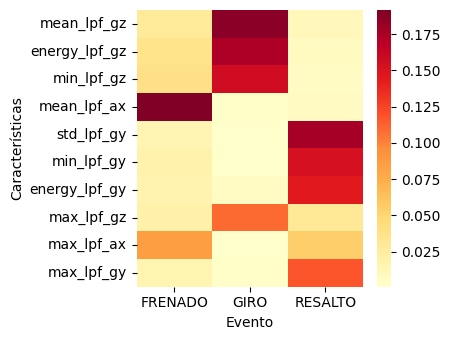

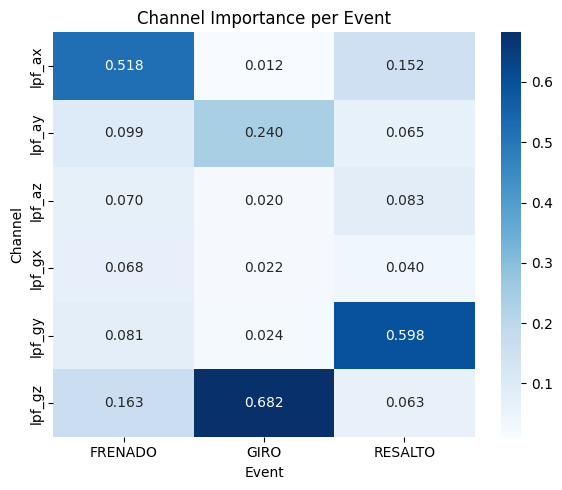


Channel Importance
         FRENADO    GIRO  RESALTO
channel                          
lpf_ax    0.5179  0.0115   0.1523
lpf_ay    0.0988  0.2401   0.0647
lpf_az    0.0704  0.0199   0.0830
lpf_gx    0.0681  0.0218   0.0396
lpf_gy    0.0814  0.0243   0.5979
lpf_gz    0.1634  0.6822   0.0625


In [13]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# =========================================================
# LOAD SESSIONS
# =========================================================
VEHICLE_DATASET_PATH = '/content/drive/MyDrive/LabeledDataset'

print("\nLoading sessions...")
sessions = load_all_sessions(VEHICLE_DATASET_PATH,
                             interpolate_missing=True,
                             target_hz=33.0,
                             agg='last',
                             print_dist=False)

BAIC_sessions = [s for s in sessions if s['car_type'] == 'BAIC']

# =========================================================
# BUILD CACHE
# =========================================================
cache = build_cache(
    BAIC_sessions,
    augment=False,
    imu_channels=['lpf_ax','lpf_ay','lpf_az','lpf_gx','lpf_gy','lpf_gz']
)

# =========================================================
# BUILD DATASET
# =========================================================

X_all = []
y_all = []

for entry in cache:

    if len(entry['Xa']) == 0:
        continue

    X_all.append(extract_features(entry['Xa']))
    y_all.append(entry['ya'])

X = np.concatenate(X_all, axis=0)
y = np.concatenate(y_all, axis=0)

# =========================================================
# FEATURE NAMES
# =========================================================

channels_raw = [
    'lpf_ax',
    'lpf_ay',
    'lpf_az',
    'lpf_gx',
    'lpf_gy',
    'lpf_gz'
]

feature_names = []

for c in channels_raw:
    feature_names.extend([
        f"mean_{c}",
        f"std_{c}",
        f"min_{c}",
        f"max_{c}",
        f"energy_{c}",
    ])

# =========================================================
# RF IMPORTANCE PER EVENT
# =========================================================

TARGET_EVENTS = [
    'FRENADO',
    'GIRO',
    'RESALTO'
]

importance_df = pd.DataFrame(index=feature_names)

for event in TARGET_EVENTS:

    y_bin = (y == event).astype(int)

    rf = RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )

    rf.fit(X, y_bin)

    importance_df[event] = rf.feature_importances_

# =========================================================
# TOP FEATURES
# =========================================================

importance_df["total"] = importance_df.sum(axis=1)

# =========================================================
# FEATURE HEATMAP
# =========================================================
top_features = (
    importance_df
    .sort_values("total", ascending=False)
    .head(10)
    .drop(columns="total")
)

plt.figure(figsize=(4.5,3.5))

sns.heatmap(
    top_features,
    cmap="YlOrRd",
    annot=False,
    cbar=True
)

plt.xlabel("Evento")
plt.ylabel("Características")
plt.tight_layout()

# =========================================================
# CHANNEL IMPORTANCE
# =========================================================

channel_df = importance_df.drop(columns="total").copy()

channel_df["channel"] = [
    "_".join(f.split("_")[-2:])
    for f in channel_df.index
]

channel_df = (
    channel_df
    .groupby("channel")
    .sum()
)

plt.figure(figsize=(6,5))

sns.heatmap(
    channel_df,
    annot=True,
    fmt=".3f",
    cmap="Blues"
)

plt.title("Channel Importance per Event")
plt.xlabel("Event")
plt.ylabel("Channel")

plt.tight_layout()
plt.show()

print("\n==============================")
print("Channel Importance")
print("==============================")
print(channel_df.round(4))

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.fft import rfft, rfftfreq


# =========================================================
# CHARACTERIZE EVENTS PER SESSION (con session_id)
# =========================================================
TARGET_EVENTS = ['FRENADO', 'GIRO', 'RESALTO']
records = []

print(f"Cache length: {len(cache)}")

for sess_idx, (session, entry) in enumerate(zip(BAIC_sessions, cache)):
    style = "AGRESIVO" if str(session['session_type']) == "BRUSCO" else "NORMAL"
    Xte, yte = entry['Xc'], entry['yc']

    for j in range(len(Xte)):
        target = yte[j]  # La etiqueta de esta ventana

        if target not in TARGET_EVENTS:
            continue

        win = Xte[j]
        ax = win[:,0]
        ay = win[:,1]
        az = win[:,2]
        gx = win[:,3]
        gy = win[:,4]
        gz = win[:,5]

        record = {
            'session_id': sess_idx,
            'style': style,
            'event': target
        }

        if target == 'FRENADO':
            record.update({
                'peak': np.max(np.abs(ax)),
                'rate': np.mean(np.abs(np.diff(ax))),
                'rms': np.sqrt(np.mean(ax**2))
            })
        elif target == 'GIRO':
            record.update({
                'peak': np.max(np.abs(gz)),
                'rate': np.mean(np.abs(np.diff(gz))),
                'rms': np.sqrt(np.mean(gz**2))
            })
        elif target == 'RESALTO':
            record.update({
                'peak': np.max(np.abs(gy)),
                'rate': np.mean(np.abs(np.diff(gy))),
                'rms':  np.sqrt(np.mean(gy**2)),
            })

        records.append(record)

df = pd.DataFrame(records)
df['style'] = df['style'].astype(str)
df['event'] = df['event'].astype(str)
df['session_id'] = df['session_id'].astype(int)

print(f"\n✅ Total eventos: {len(df)}")
print(df.groupby(['style', 'event']).size().unstack(fill_value=0))

Cache length: 6

✅ Total eventos: 128
event     FRENADO  GIRO  RESALTO
style                           
AGRESIVO       39    14        6
NORMAL         39    21        9


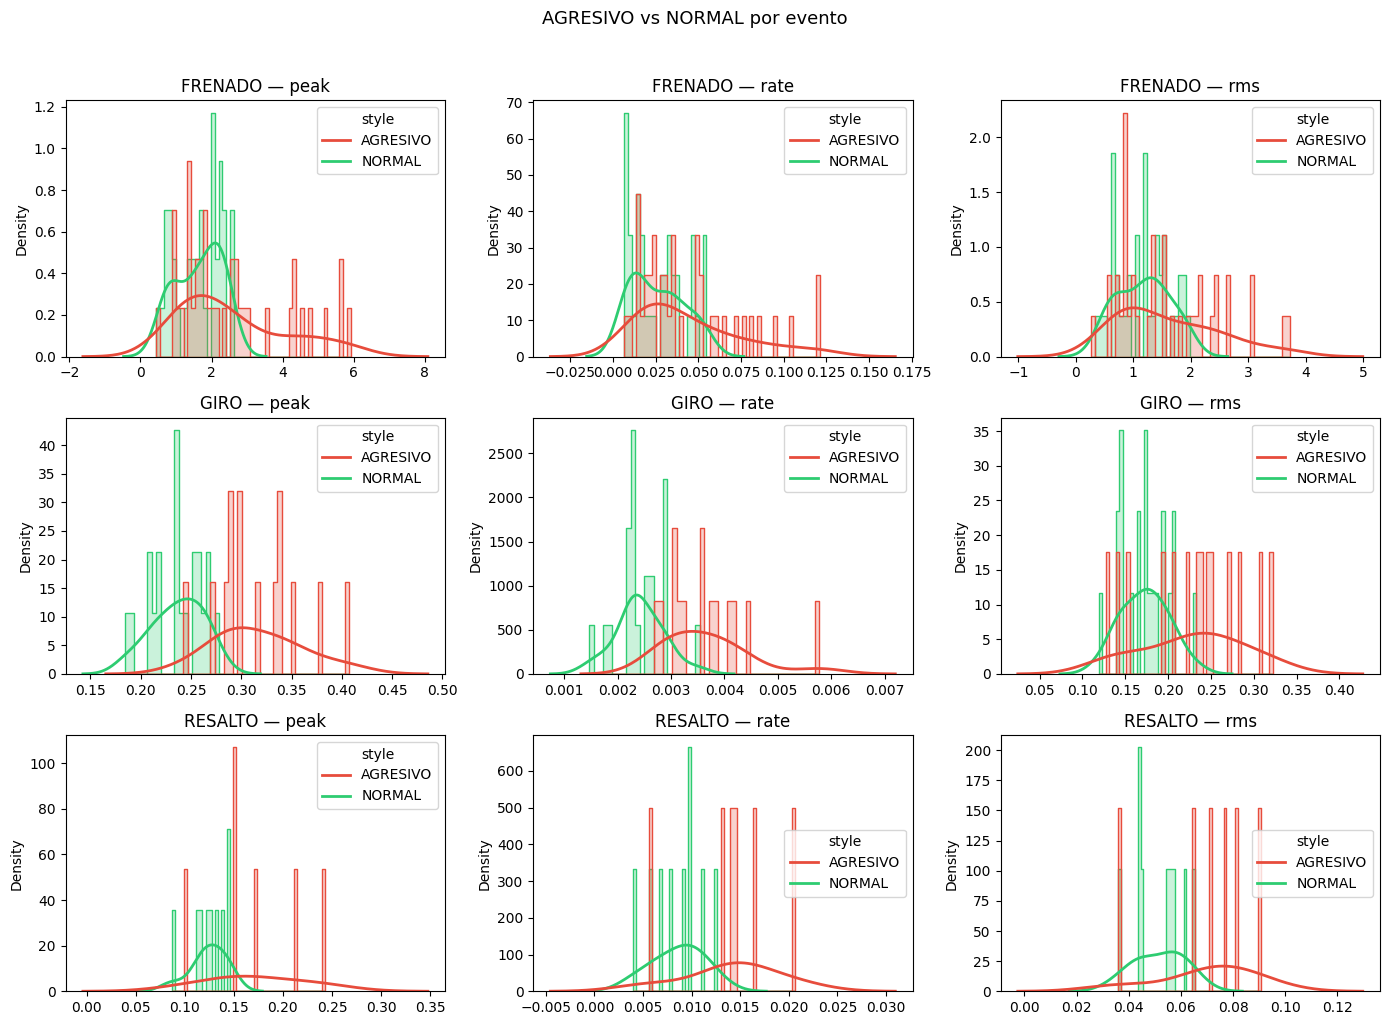


Mann-Whitney U Test + Effect Size:
Evento       Feature     p-value    Effect Size
-------------------------------------------------------
FRENADO      peak         0.0040         0.3491
FRENADO      rate         0.0028         0.3649
FRENADO      rms          0.0234         0.2623
GIRO         peak         0.0000         0.9320
GIRO         rate         0.0000         0.9048
GIRO         rms          0.0027         0.5646
RESALTO      peak         0.0128         0.7037
RESALTO      rate         0.0128         0.7037
RESALTO      rms          0.0180         0.6667

Pesos por feature (dentro de cada evento):
  FRENADO: {'peak': np.float64(0.358), 'rate': np.float64(0.374), 'rms': np.float64(0.269)}
  GIRO: {'peak': np.float64(0.388), 'rate': np.float64(0.377), 'rms': np.float64(0.235)}
  RESALTO: {'peak': np.float64(0.339), 'rate': np.float64(0.339), 'rms': np.float64(0.321)}

Pesos entre eventos (para score de sesión):
{'FRENADO': np.float64(0.179), 'GIRO': np.float64(0.44), 'RESALTO'

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

features_to_plot = ['peak', 'rate', 'rms']

fig, axes = plt.subplots(len(TARGET_EVENTS), len(features_to_plot),
                         figsize=(14, 10))

for row, event in enumerate(TARGET_EVENTS):
    subset = df[df['event'] == event]

    for col, feat in enumerate(features_to_plot):
        ax = axes[row, col]

        sns.histplot(
            data=subset,
            x=feat,
            hue='style',
            stat='density',
            bins=50,
            element='step',
            common_norm=False,
            palette={'AGRESIVO': '#e74c3c', 'NORMAL': '#2ecc71'},
            alpha=0.25,
            ax=ax
        )

        sns.kdeplot(
            data=subset,
            x=feat,
            hue='style',
            fill=False,
            common_norm=False,
            palette={'AGRESIVO': '#e74c3c', 'NORMAL': '#2ecc71'},
            linewidth=2,
            ax=ax
        )

        ax.set_title(f'{event} — {feat}')
        ax.set_xlabel('')
        ax.set_ylabel('Density')

plt.suptitle('AGRESIVO vs NORMAL por evento',
             fontsize=13, y=1.02)

plt.tight_layout()
plt.show()

# =========================================================
# MANN-WHITNEY + EFFECT SIZE → PESOS
# =========================================================
print("\nMann-Whitney U Test + Effect Size:")
print(f"{'Evento':12} {'Feature':8} {'p-value':>10} {'Effect Size':>14}")
print("-" * 55)

effect_sizes = {}

for event in TARGET_EVENTS:
    effect_sizes[event] = {}
    for feat in features_to_plot:
        brusco = df[(df['event'] == event) & (df['style'] == 'AGRESIVO')][feat].values
        normal = df[(df['event'] == event) & (df['style'] == 'NORMAL')][feat].values

        if len(brusco) > 0 and len(normal) > 0:
            stat, p = mannwhitneyu(brusco, normal, alternative='greater')
            n1, n2  = len(brusco), len(normal)
            r = (2 * stat) / (n1 * n2) -1  # abs() garantiza r positivo
            effect_sizes[event][feat] = r
            print(f"{event:12} {feat:8} {p:>10.4f} {r:>14.4f}")

# # Pesos por evento normalizados desde effect size
weights = {}
for event in TARGET_EVENTS:
    total_r = sum(effect_sizes[event].values())
    weights[event] = {feat: r / total_r for feat, r in effect_sizes[event].items()}

# Pesos entre eventos (para el score de sesión)
event_mean_r = {e: np.mean(list(effect_sizes[e].values())) for e in TARGET_EVENTS}
total_event_r = sum(event_mean_r.values())
event_weights = {e: v / total_event_r for e, v in event_mean_r.items()}

print("\nPesos por feature (dentro de cada evento):")
for event, w in weights.items():
    print(f"  {event}: { {k: round(v,3) for k,v in w.items()} }")

print("\nPesos entre eventos (para score de sesión):")
print({e: round(v, 3) for e, v in event_weights.items()})


P10 / P90 per Event + Feature:
--------------------------------------------------------------------------------

FRENADO
  peak       | B10=1.0260  B90=4.8320  | N10=0.7471  N90=2.3753
  rate       | B10=0.0151  B90=0.0884  | N10=0.0075  N90=0.0480
  rms        | B10=0.7301  B90=2.7381  | N10=0.6197  N90=1.8271

GIRO
  peak       | B10=0.2753  B90=0.3710  | N10=0.2073  N90=0.2652
  rate       | B10=0.0028  B90=0.0044  | N10=0.0018  N90=0.0029
  rms        | B10=0.1440  B90=0.3004  | N10=0.1423  N90=0.2068

RESALTO
  peak       | B10=0.1255  B90=0.2274  | N10=0.1080  N90=0.1442
  rate       | B10=0.0094  B90=0.0186  | N10=0.0055  N90=0.0114
  rms        | B10=0.0506  B90=0.0859  | N10=0.0425  N90=0.0623

── Session Scores ──────────────────────────────────────────
 session_id    style  rate_FRENADO  rate_GIRO  rate_RESALTO  session_score
          2 AGRESIVO         54.10      80.17         93.38          80.53
          1 AGRESIVO         75.80      76.78         62.24          71.07


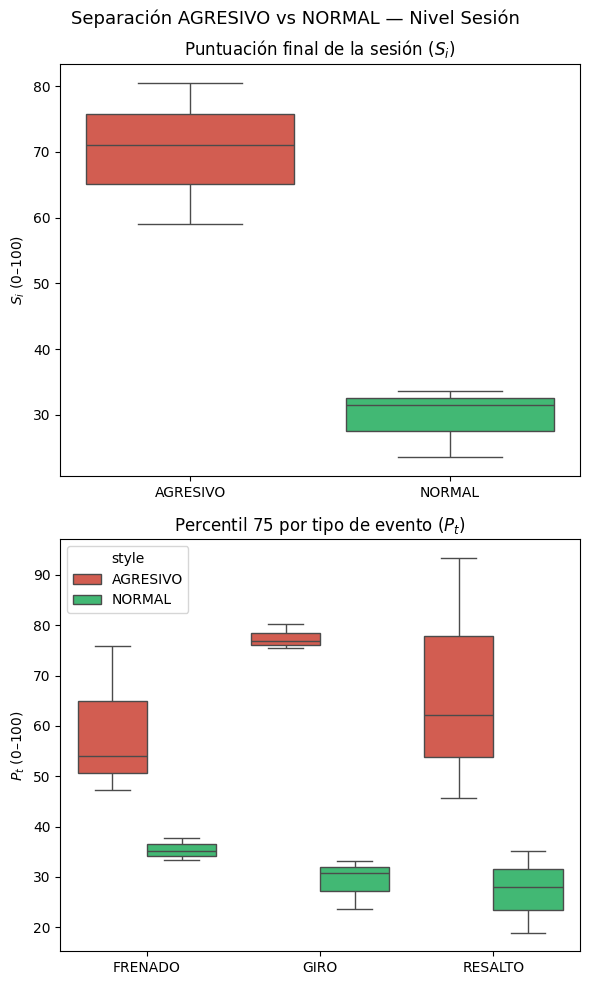


── Estadísticas session_score ───────────────────────────────
          count   mean    std    min    25%    50%    75%    max
style                                                           
AGRESIVO    3.0  70.20  10.79  59.01  65.04  71.07  75.80  80.53
NORMAL      3.0  29.57   5.30  23.57  27.55  31.53  32.58  33.62


In [16]:
# =========================================================
# P10 / P90
# =========================================================
print("\nP10 / P90 per Event + Feature:")
print("-" * 80)

for event in TARGET_EVENTS:
    print(f"\n{event}")
    for feat in features_to_plot:
        brusco = df[(df['event'] == event) & (df['style'] == 'AGRESIVO')][feat].values
        normal = df[(df['event'] == event) & (df['style'] == 'NORMAL')][feat].values
        print(f"  {feat:10} | "
              f"B10={np.percentile(brusco,10):.4f}  B90={np.percentile(brusco,90):.4f}  | "
              f"N10={np.percentile(normal,10):.4f}  N90={np.percentile(normal,90):.4f}")

# =========================================================
# COMPUTE SCORE POR VENTANA
# =========================================================
def compute_score(df, features, weights, event, low_pct=10, high_pct=90):
    # brusco = df[(df['event'] == event) & (df['style'] == 'AGRESIVO')][feat].values
    # normal = df[(df['event'] == event) & (df['style'] == 'NORMAL')][feat].values

    ref_normal = df[(df['event'] == event) & (df['style'] == 'NORMAL')]
    ref_brusco = df[(df['event'] == event) & (df['style'] == 'AGRESIVO')]
    target     = df[df['event'] == event].copy()

    for feat in features:
        low  = np.percentile(ref_normal[feat].values, low_pct)
        high = np.percentile(ref_brusco[feat].values, high_pct)
        target[f'score_{feat}'] = target[feat].apply(
            lambda x: float(np.clip((x - low) / (high - low) * 100, 0, 100))
        )

    target['score_final'] = sum(
        weights[feat] * target[f'score_{feat}'] for feat in features
    )
    return target

features = ['peak', 'rate', 'rms']

scored_frames = []
for event in TARGET_EVENTS:
    scored = compute_score(df, features=features, weights=weights[event], event=event)
    scored_frames.append(scored)

df_scored = pd.concat(scored_frames, ignore_index=True)

# =========================================================
# SCORE POR SESIÓN
# =========================================================
session_records = []

for sess_id in sorted(df_scored['session_id'].unique()):
    sess_df = df_scored[df_scored['session_id'] == sess_id]
    style   = sess_df['style'].iloc[0]
    row     = {'session_id': sess_id, 'style': style}

    weighted_sum   = 0.0
    weight_total   = 0.0

    for event in TARGET_EVENTS:
        ev_df = sess_df[sess_df['event'] == event]

        if len(ev_df) == 0:
            row[f'rate_{event}']  = np.nan
            row[f'n_{event}']     = 0
            continue

        rate = np.percentile(ev_df['score_final'], 75) / 100.0 if len(ev_df) > 0 else 0.0
        row[f'rate_{event}'] = round(rate, 4)*100
        row[f'n_{event}']    = len(ev_df)

        # Acumula score ponderado por event_weight
        weighted_sum  += event_weights[event] * rate
        weight_total  += event_weights[event]

    # Normaliza por los eventos que sí tienen datos
    row['session_score'] = round(
        (weighted_sum / weight_total) * 100 if weight_total > 0 else np.nan, 2
    )
    session_records.append(row)

df_sessions = pd.DataFrame(session_records)

rate_cols = [f'rate_{e}' for e in TARGET_EVENTS]
n_cols    = [f'n_{e}'    for e in TARGET_EVENTS]

print("\n── Session Scores ──────────────────────────────────────────")
print(df_sessions[['session_id', 'style', *rate_cols, 'session_score']]
      .sort_values('session_score', ascending=False)
      .to_string(index=False))

# =========================================================
# VALIDACIÓN — BOXPLOT SESSION SCORE
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(6, 10))

# Score global
sns.boxplot(data=df_sessions, x='style', y='session_score',
            palette={'AGRESIVO': '#e74c3c', 'NORMAL': '#2ecc71'},
            ax=axes[0])
axes[0].set_title(r'Puntuación final de la sesión ($S_i$)')
axes[0].set_ylabel(r'$S_i$ (0–100)')
axes[0].set_xlabel('')

# Rate por evento (long format)
rate_long = df_sessions[['style', *rate_cols]].melt(
    id_vars='style', var_name='event', value_name='rate'
)
rate_long['event'] = rate_long['event'].str.replace('rate_', '')

sns.boxplot(data=rate_long, x='event', y='rate', hue='style',
            palette={'AGRESIVO': '#e74c3c', 'NORMAL': '#2ecc71'},
            ax=axes[1])
axes[1].set_title(r'Percentil 75 por tipo de evento ($P_t$)')
axes[1].set_ylabel(r'$P_t$ (0–100)')
axes[1].set_xlabel('')

plt.suptitle('Separación AGRESIVO vs NORMAL — Nivel Sesión', fontsize=13)
plt.tight_layout()
plt.show()

# =========================================================
# ESTADÍSTICAS FINALES
# =========================================================
print("\n── Estadísticas session_score ───────────────────────────────")
print(df_sessions.groupby('style')['session_score'].describe().round(2))

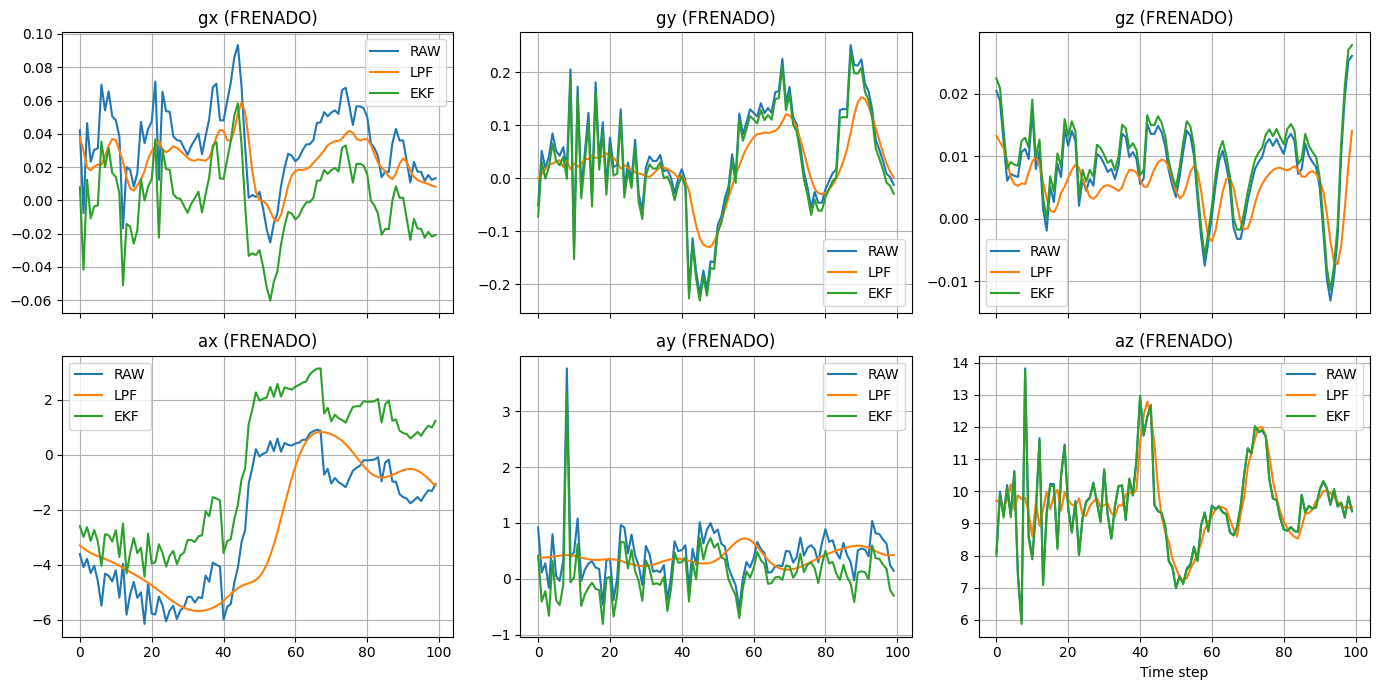

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# ── seleccionar sesión válida ──
session = None
for s in BAIC_sessions:
    cols = s['imu_df'].columns.tolist()
    if all(c in cols for c in ['gx', 'lpf_gx']):
        session = s
        break

assert session is not None, "No valid session found"

# ── canales ──
gyro_raw = ['gx','gy','gz']
gyro_lpf = ['lpf_gx','lpf_gy','lpf_gz']
gyro_ekf = ['ekf_gx','ekf_gy','ekf_gz']

acc_raw = ['ax','ay','az']
acc_lpf = ['lpf_ax','lpf_ay','lpf_az']
acc_ekf = ['ekf_ax','ekf_ay','ekf_az']

# ── ventanas + labels ──
X_g_raw, y = build_windows_for_session(session, imu_channels=gyro_raw, augment=False)
X_g_lpf, _ = build_windows_for_session(session, imu_channels=gyro_lpf, augment=False)
X_g_ekf, _ = build_windows_for_session(session, imu_channels=gyro_ekf, augment=False)

X_a_raw, _ = build_windows_for_session(session, imu_channels=acc_raw, augment=False)
X_a_lpf, _ = build_windows_for_session(session, imu_channels=acc_lpf, augment=False)
X_a_ekf, _ = build_windows_for_session(session, imu_channels=acc_ekf, augment=False)

# ── elegir clase de interés ──
target_class = "FRENADO"   # <-- cambia esto a tu label real

idx = np.where(y == target_class)[0]

assert len(idx) > 0, f"No windows found for class {target_class}"

# ── seleccionar una ventana de esa clase ──
Wn = idx[2]   # o np.random.choice(idx)

g_raw = X_g_raw[Wn]
g_lpf = X_g_lpf[Wn]
g_ekf = X_g_ekf[Wn]

a_raw = X_a_raw[Wn]
a_lpf = X_a_lpf[Wn]
a_ekf = X_a_ekf[Wn]
a_ekf[:,2] = a_ekf[:,2] + 9.81

# ── plot ──
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)

labels_g = ['gx', 'gy', 'gz']
labels_a = ['ax', 'ay', 'az']

# ── gyro ──
for i in range(3):
    axes[0, i].plot(g_raw[:, i], label='RAW')
    axes[0, i].plot(g_lpf[:, i], label='LPF')
    axes[0, i].plot(g_ekf[:, i], label='EKF')
    axes[0, i].set_title(f"{labels_g[i]} ({target_class})")
    axes[0, i].legend()
    axes[0, i].grid()

# ── accel ──
for i in range(3):
    axes[1, i].plot(a_raw[:, i], label='RAW')
    axes[1, i].plot(a_lpf[:, i], label='LPF')
    axes[1, i].plot(a_ekf[:, i], label='EKF')
    axes[1, i].set_title(f"{labels_a[i]} ({target_class})")
    axes[1, i].legend()
    axes[1, i].grid()

plt.xlabel("Time step")
plt.tight_layout()
plt.show()